# Eda on Time Serie (Product)

In this notebook we do a quick time series EDA to understand how demand behaves over time.

We will:
1.	Plot a few product time series (trend + peaks).
2.	Plot weekday seasonality (average demand by Monday/Tuesday/…).
3.	Plot ACF / PACF on 1–2 series to illustrate short-term dependence and weekly seasonality.
4.	Export 3 or 4 figures into a reports/figures/ folder.

In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import STL
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf


In [15]:
# Create folder to export figures
FIG_DIR = "reports/TS_EDA_figures"
os.makedirs(FIG_DIR, exist_ok=True)

## Load product time series (qty_ts, rev_ts)

We load the daily time series produced in Step 2:
	•	qty_ts: daily quantities sold per product (12 columns)
	•	rev_ts: daily revenue per product (12 columns)

In [3]:
# Load qty_ts and rev_ts from CSV (recommended)
# Adjust paths if needed
qty_path = "data_tmp/qty_ts.csv"
rev_path = "data_tmp/rev_ts.csv"

qty_ts = pd.read_csv(qty_path, index_col=0, parse_dates=True)
rev_ts = pd.read_csv(rev_path, index_col=0, parse_dates=True)

print("qty_ts shape:", qty_ts.shape)
print("rev_ts shape:", rev_ts.shape)
qty_ts.head()

qty_ts shape: (600, 12)
rev_ts shape: (600, 12)


,BAGUETTE,BANETTE,BOULE 400G,CAMPAGNE,CEREAL BAGUETTE,COOKIE,CROISSANT,ECLAIR,PAIN AU CHOCOLAT,SPECIAL BREAD,TARTELETTE,TRADITIONAL BAGUETTE
date,,,,,,,,,,,,
2021-01-02,46.0,40.0,11.0,10.0,19.0,8.0,66.0,0.0,48.0,8.0,0.0,128.0
2021-01-03,35.0,35.0,11.0,9.0,16.0,2.0,59.0,0.0,45.0,7.0,0.0,171.0
2021-01-04,30.0,24.0,5.0,6.0,7.0,2.0,17.0,0.0,17.0,7.0,0.0,128.0
2021-01-05,29.0,26.0,6.0,3.0,7.0,6.0,12.0,0.0,6.0,7.0,0.0,99.0
2021-01-07,28.0,21.0,3.0,3.0,7.0,3.0,15.0,0.0,15.0,6.0,0.0,109.0


In [4]:
total_qty_by_product = qty_ts.sum().sort_values(ascending=False)
total_qty_by_product

TRADITIONAL BAGUETTE    117456.0
CROISSANT                29677.0
PAIN AU CHOCOLAT         25244.0
BANETTE                  22731.0
BAGUETTE                 22059.0
CEREAL BAGUETTE           7426.0
SPECIAL BREAD             5458.0
TARTELETTE                5012.0
BOULE 400G                4822.0
CAMPAGNE                  4356.0
COOKIE                    3779.0
ECLAIR                    3655.0
dtype: float64

In [5]:
# Choose top 3 products
TOP_N_PRODUCTS = 12
top_products = list(total_qty_by_product.head(TOP_N_PRODUCTS).index)
top_products

['TRADITIONAL BAGUETTE',
 'CROISSANT',
 'PAIN AU CHOCOLAT',
 'BANETTE',
 'BAGUETTE',
 'CEREAL BAGUETTE',
 'SPECIAL BREAD',
 'TARTELETTE',
 'BOULE 400G',
 'CAMPAGNE',
 'COOKIE',
 'ECLAIR']

##  Helper plotting functions

We define a few small helper functions:
- plot a time series
- weekday seasonality (mean per day of week)
- ACF/PACF plots (with a fallback if statsmodels is not installed)

In [6]:
#Helper functions for plotting

def save_show(fig, filename):
    path = os.path.join(FIG_DIR, filename)
    fig.savefig(path, dpi=200, bbox_inches="tight")
    print("Saved:", path)
    plt.show()

def plot_series(series: pd.Series, title: str, ylabel: str, save_name: str = None):
    plt.figure(figsize=(12, 4))
    plt.plot(series.index, series.values)
    plt.title(title)
    plt.xlabel("Date")
    plt.ylabel(ylabel)
    plt.tight_layout()
    if save_name:
        path = os.path.join(FIG_DIR, save_name)
        plt.savefig(path, dpi=200)
        print("Saved:", path)
    plt.show()


def weekday_seasonality(series: pd.Series) -> pd.Series:
    # Monday=0 ... Sunday=6
    tmp = series.copy()
    tmp.index = pd.to_datetime(tmp.index)
    means = tmp.groupby(tmp.index.dayofweek).mean()

    # Map to names
    names = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
    means.index = [names[i] for i in means.index]
    return means


def plot_weekday_bar(means: pd.Series, title: str, ylabel: str, save_name: str = None):
    plt.figure(figsize=(8, 4))
    plt.bar(means.index, means.values)
    plt.title(title)
    plt.xlabel("Day of week")
    plt.ylabel(ylabel)
    plt.tight_layout()
    if save_name:
        path = os.path.join(FIG_DIR, save_name)
        plt.savefig(path, dpi=200)
        print("Saved:", path)
    plt.show()

In [7]:
# ACF / PACF with statsmodels 
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

def plot_acf_pacf(series, lags=35, save_prefix=None):
    x = series.dropna()

    # ACF
    fig1 = plot_acf(x, lags=lags)
    fig1.set_size_inches(10, 4)
    fig1.suptitle(f"{save_prefix} ACF")
    fig1.tight_layout()
    if save_prefix:
        fig1.savefig(os.path.join(FIG_DIR, f"{save_prefix}_acf.png"), dpi=200)
    plt.show()

    # PACF
    fig2 = plot_pacf(x, lags=lags, method="ywm")
    fig2.set_size_inches(10, 4)
    fig2.suptitle(f"{save_prefix} PACF")
    fig2.tight_layout()
    if save_prefix:
        fig2.savefig(os.path.join(FIG_DIR, f"{save_prefix}_pacf.png"), dpi=200)
    plt.show()

## 1) Plot product demand series (trend + peaks)

We plot daily quantities for a few top products to see:
	•	stability vs volatility
	•	peaks
	•	possible weekly patterns (repeating cycles)


Saved: reports/figures/TRADITIONAL BAGUETTE_quantity_timeseries.png


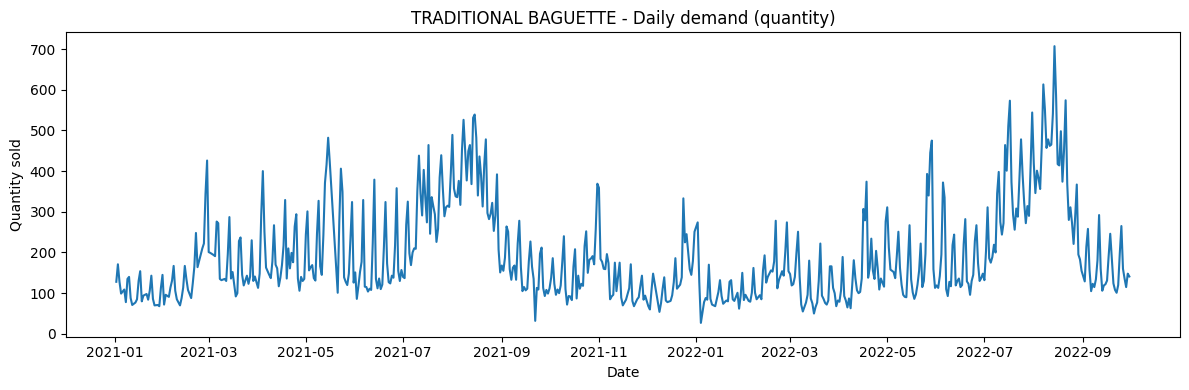

Saved: reports/figures/CROISSANT_quantity_timeseries.png


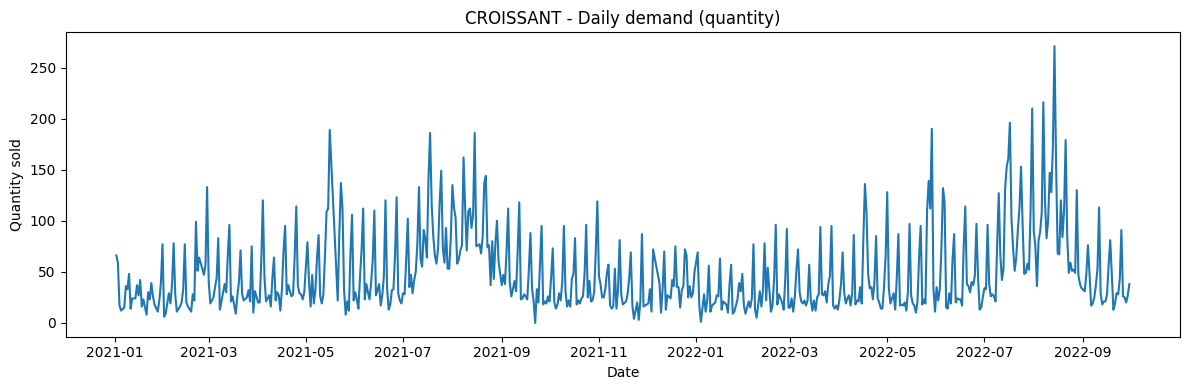

Saved: reports/figures/PAIN AU CHOCOLAT_quantity_timeseries.png


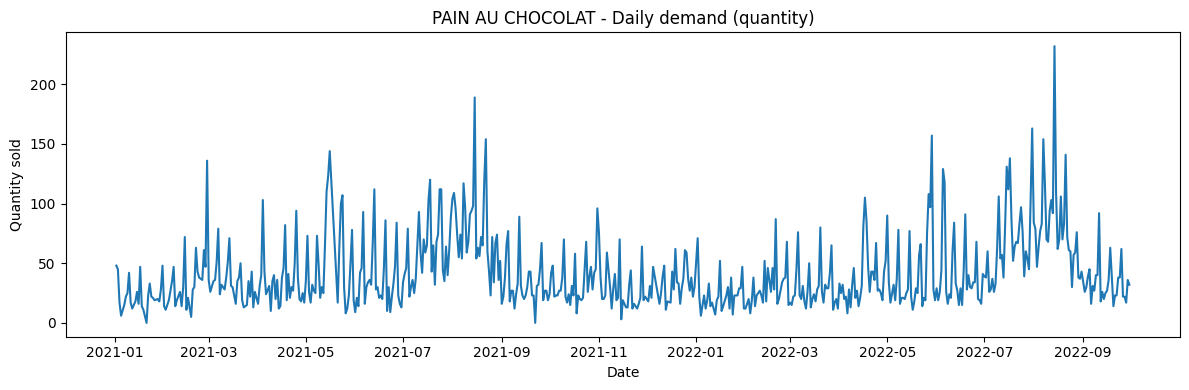

Saved: reports/figures/BANETTE_quantity_timeseries.png


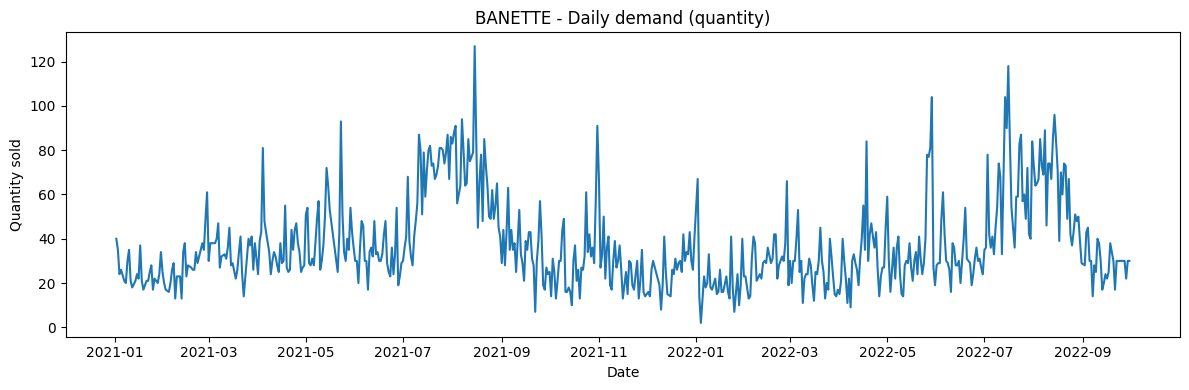

Saved: reports/figures/BAGUETTE_quantity_timeseries.png


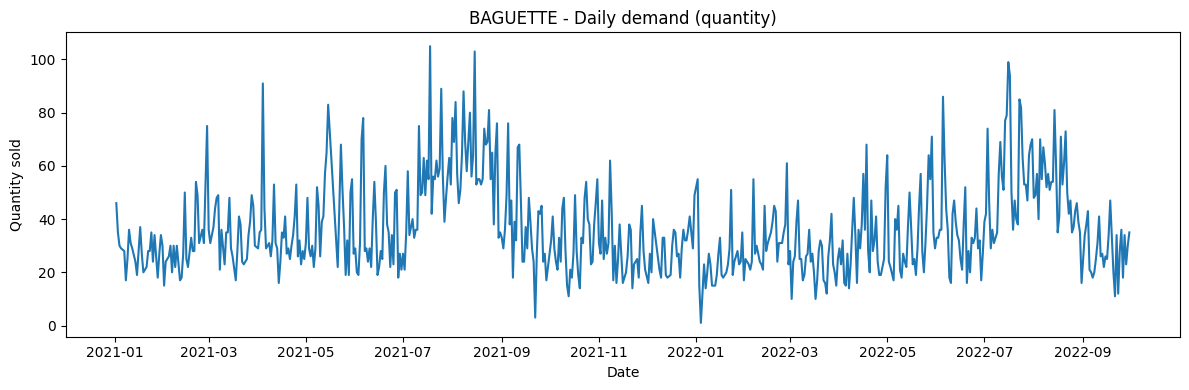

Saved: reports/figures/CEREAL BAGUETTE_quantity_timeseries.png


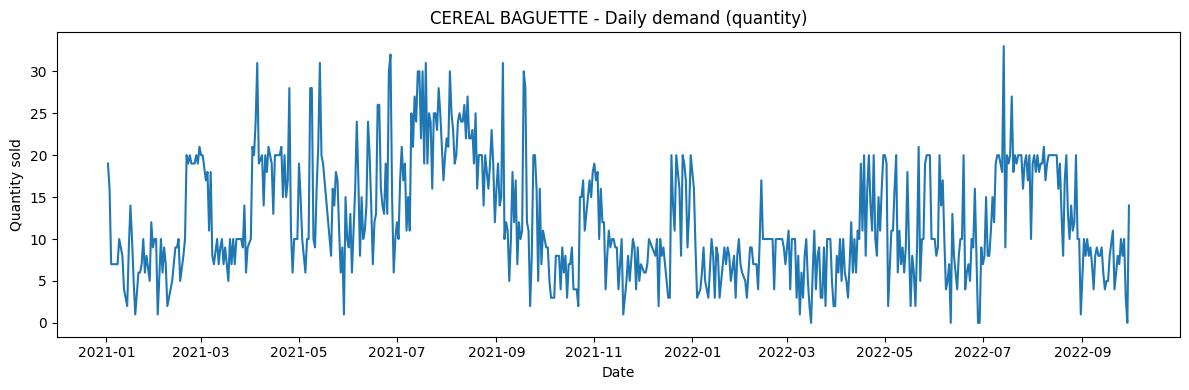

Saved: reports/figures/SPECIAL BREAD_quantity_timeseries.png


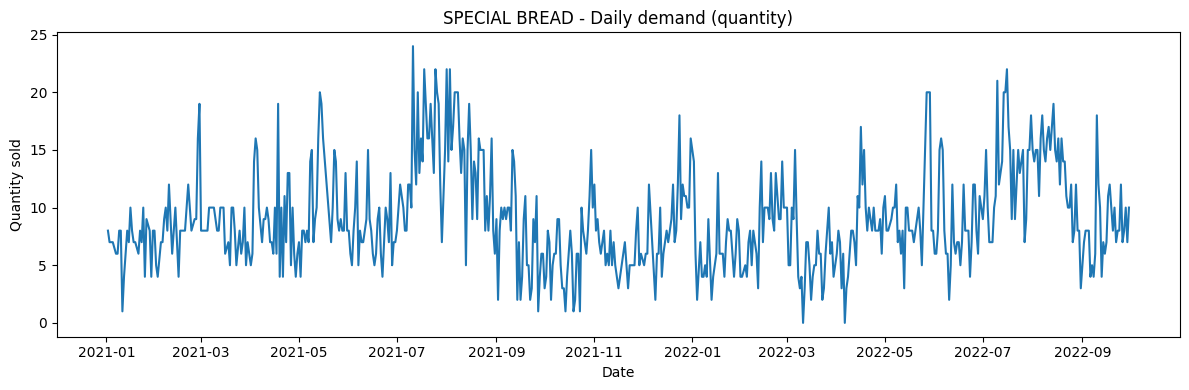

Saved: reports/figures/TARTELETTE_quantity_timeseries.png


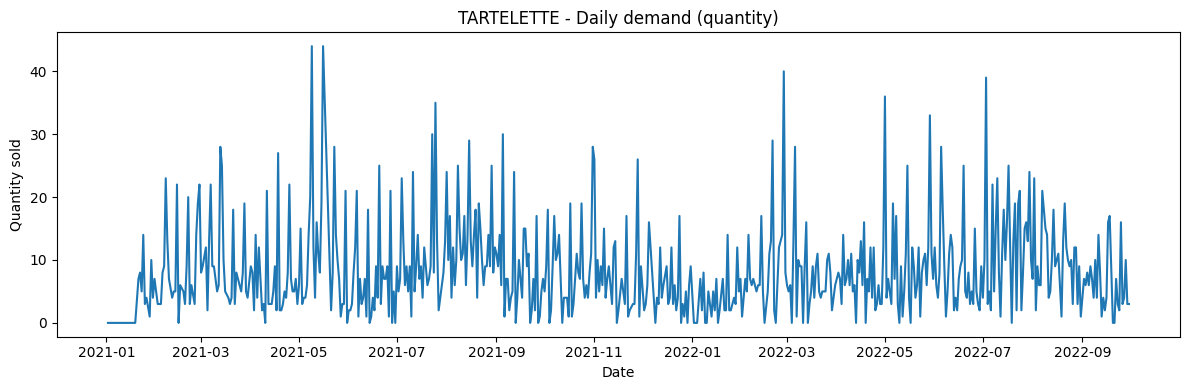

Saved: reports/figures/BOULE 400G_quantity_timeseries.png


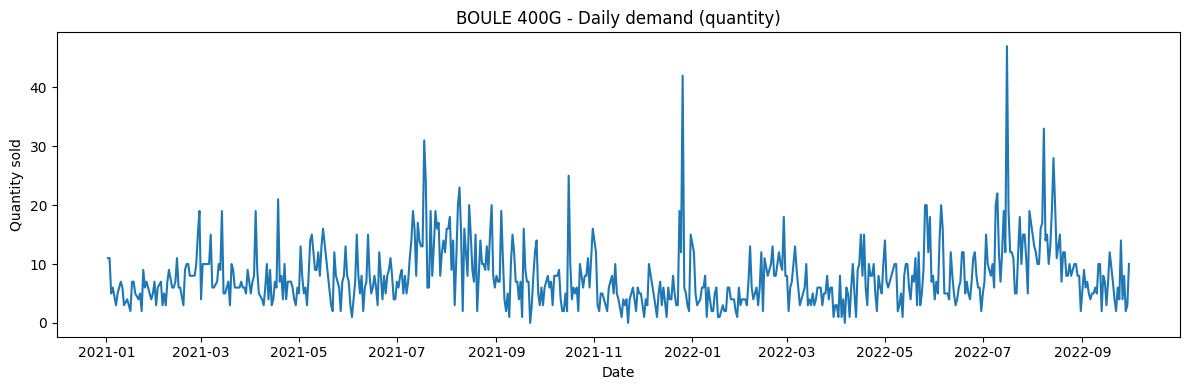

Saved: reports/figures/CAMPAGNE_quantity_timeseries.png


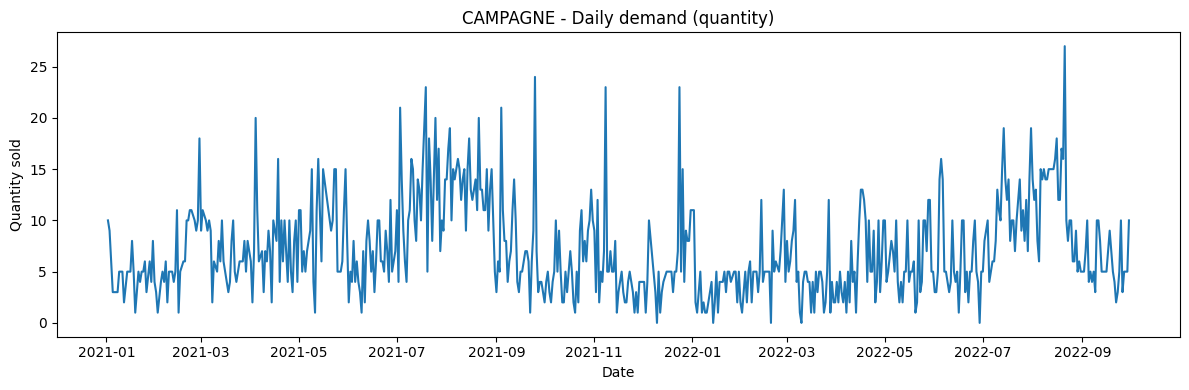

Saved: reports/figures/COOKIE_quantity_timeseries.png


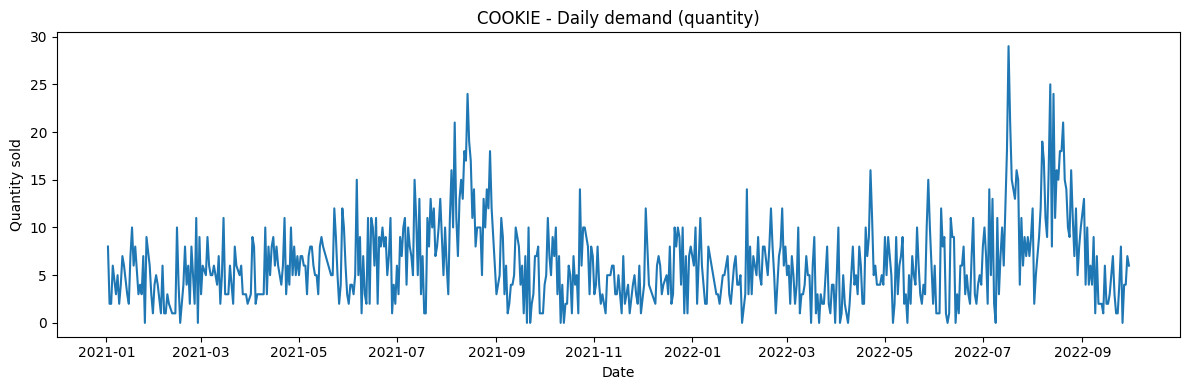

Saved: reports/figures/ECLAIR_quantity_timeseries.png


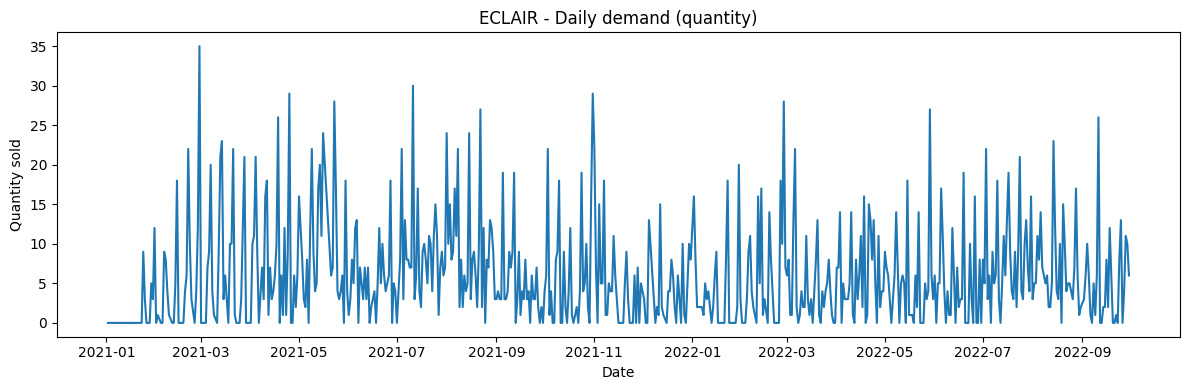

In [8]:
# Plot top product demand time series (quantity)
for p in top_products:
    s = qty_ts[p]
    plot_series(
        s,
        title=f"{p} - Daily demand (quantity)",
        ylabel="Quantity sold",
        save_name=f"{p}_quantity_timeseries.png"
    )

## 2) Weekday seasonality (product)

We compute the average quantity sold per weekday (Mon–Sun) for all product.

⸻


Saved: reports/figures/TRADITIONAL BAGUETTE_weekday_seasonality.png


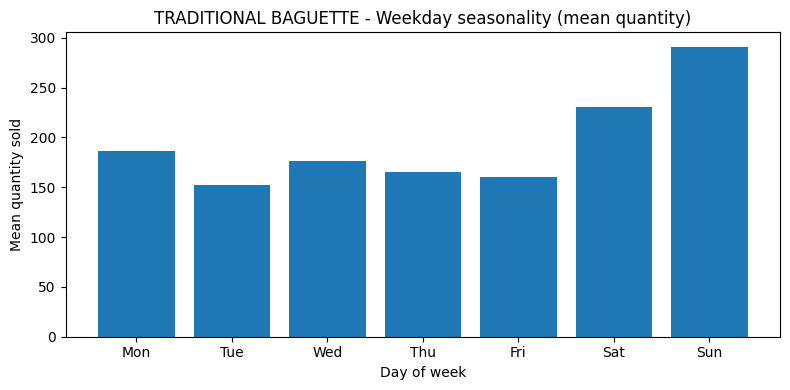

Saved: reports/figures/CROISSANT_weekday_seasonality.png


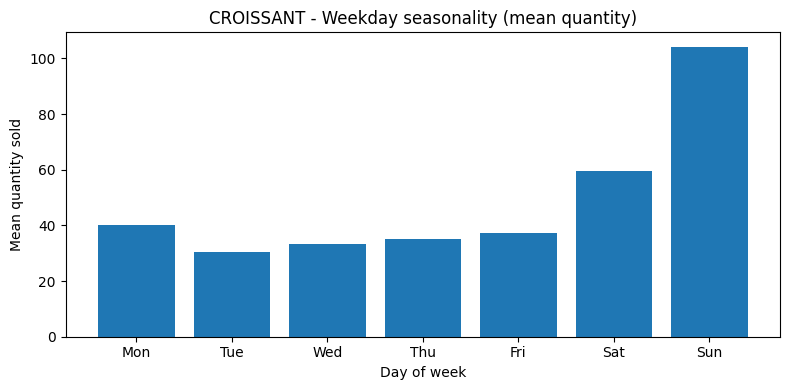

Saved: reports/figures/PAIN AU CHOCOLAT_weekday_seasonality.png


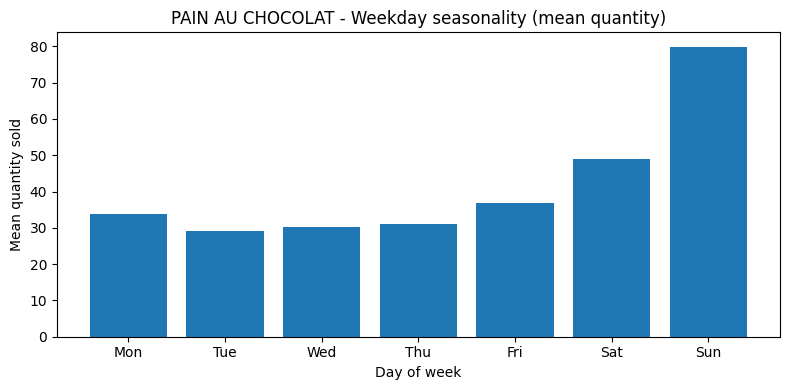

Saved: reports/figures/BANETTE_weekday_seasonality.png


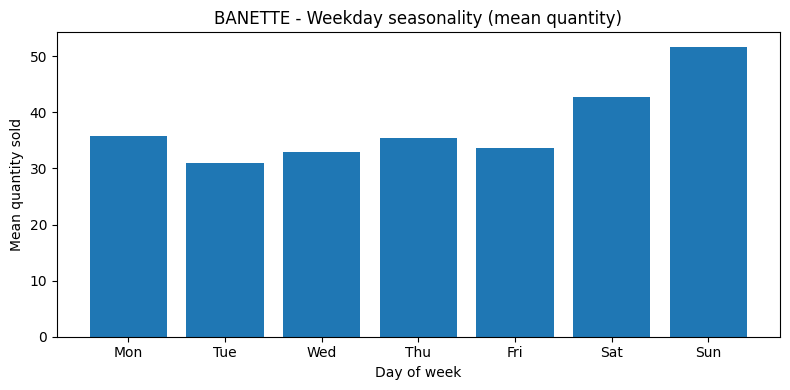

Saved: reports/figures/BAGUETTE_weekday_seasonality.png


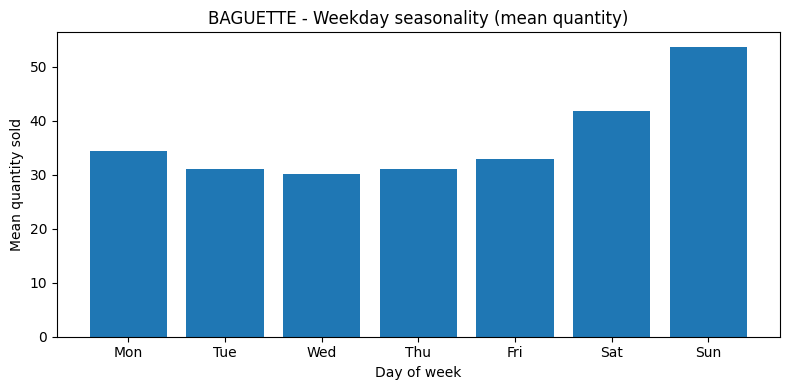

Saved: reports/figures/CEREAL BAGUETTE_weekday_seasonality.png


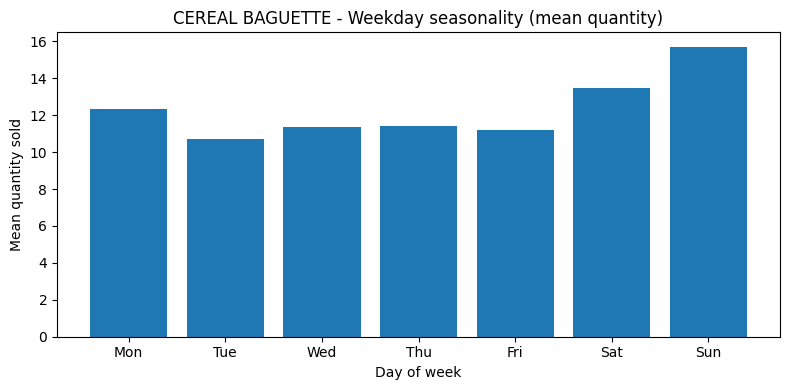

Saved: reports/figures/SPECIAL BREAD_weekday_seasonality.png


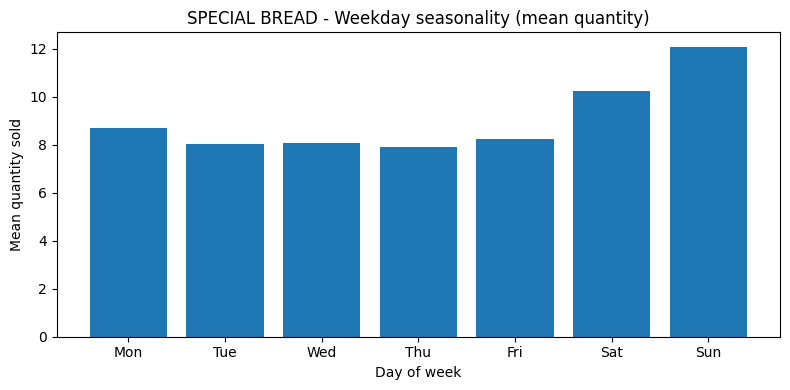

Saved: reports/figures/TARTELETTE_weekday_seasonality.png


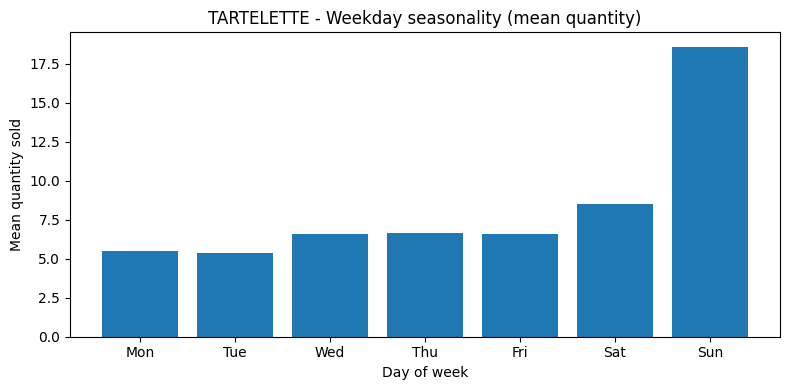

Saved: reports/figures/BOULE 400G_weekday_seasonality.png


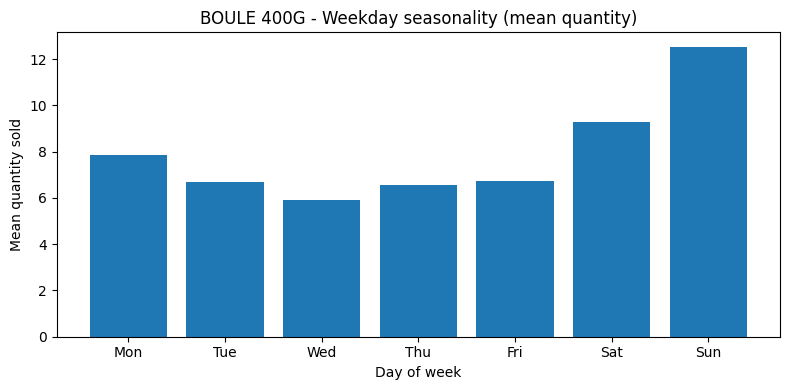

Saved: reports/figures/CAMPAGNE_weekday_seasonality.png


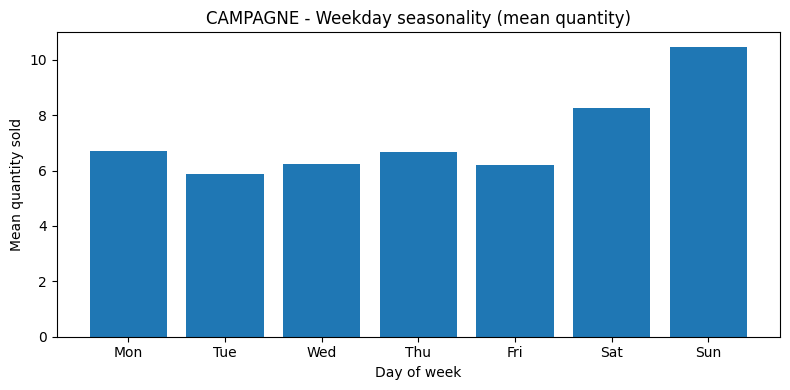

Saved: reports/figures/COOKIE_weekday_seasonality.png


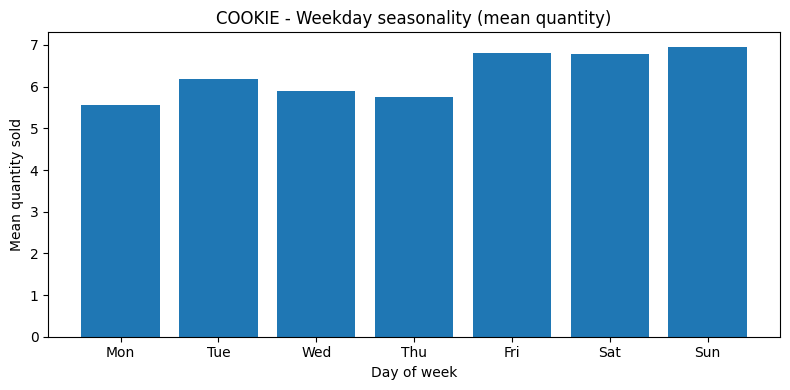

Saved: reports/figures/ECLAIR_weekday_seasonality.png


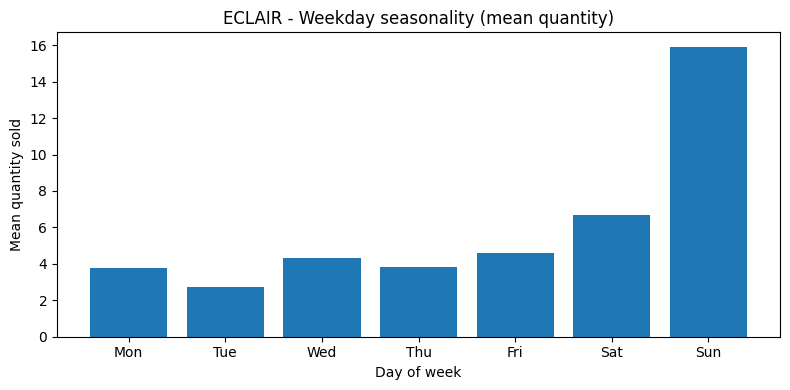

In [9]:
#Weekday seasonality for the most sold product
for p in top_products:
    product_for_weekday = p

    means = weekday_seasonality(qty_ts[product_for_weekday])

    plot_weekday_bar(
        means,
        title=f"{product_for_weekday} - Weekday seasonality (mean quantity)",
        ylabel="Mean quantity sold",
        save_name=f"{product_for_weekday}_weekday_seasonality.png"
    )

## 3) ACF/PACF (product)

We plot ACF/PACF for one product series to illustrate:
	•	short-term dependence (lags 1, 2, …)
	•	weekly seasonality (often visible around lag 7)

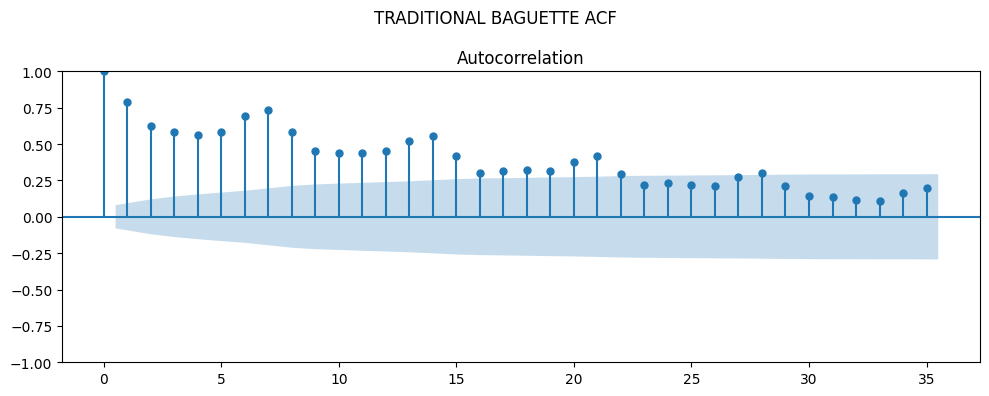

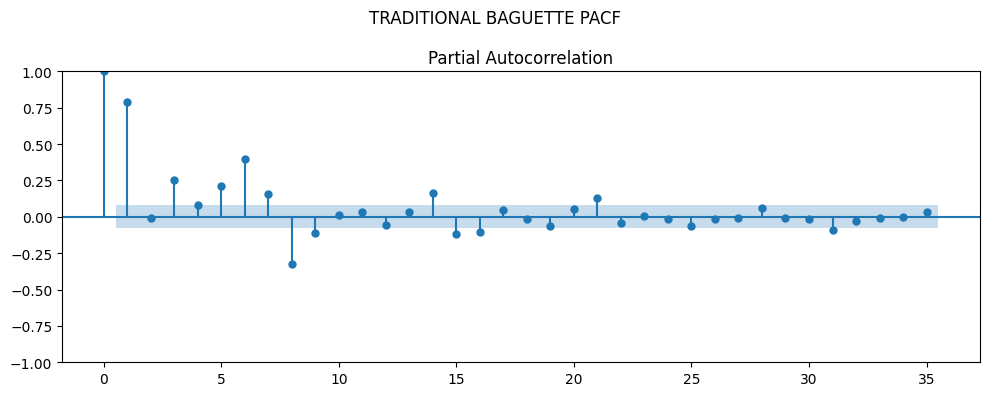

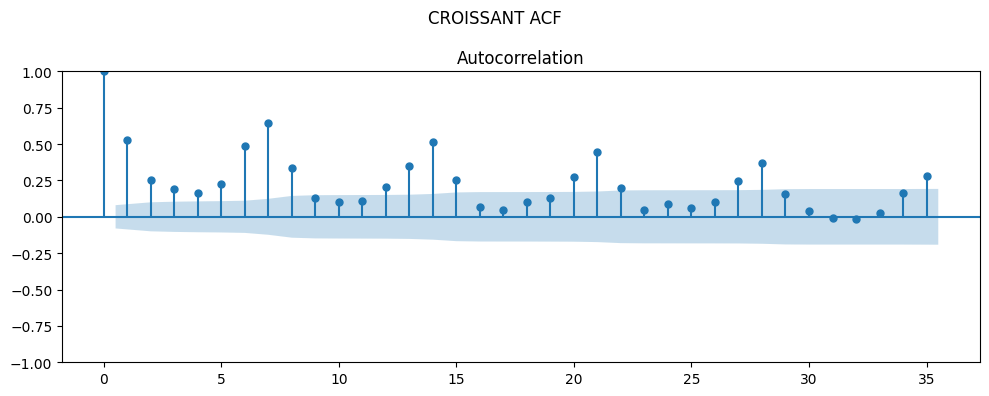

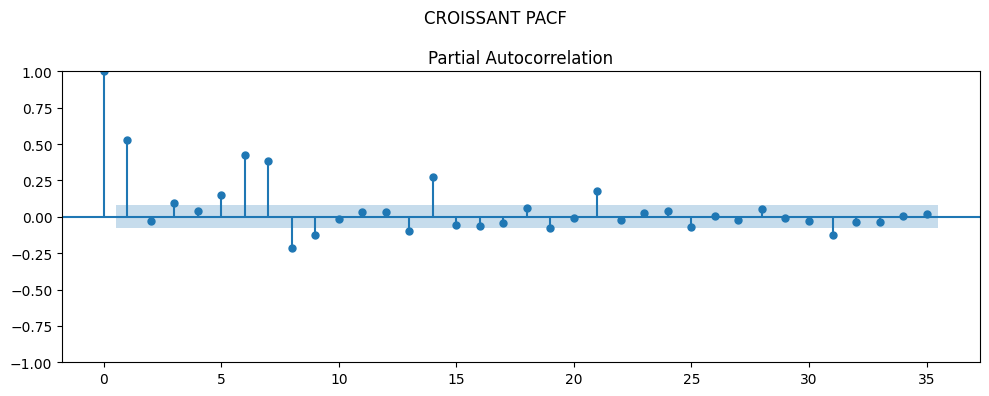

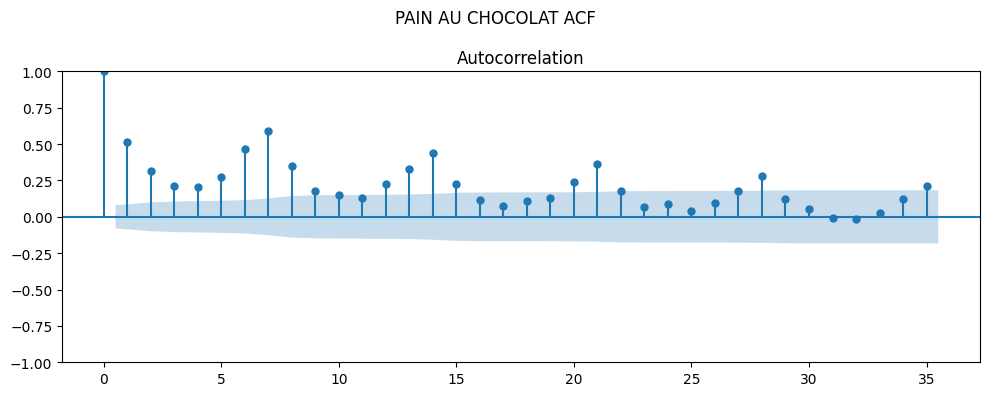

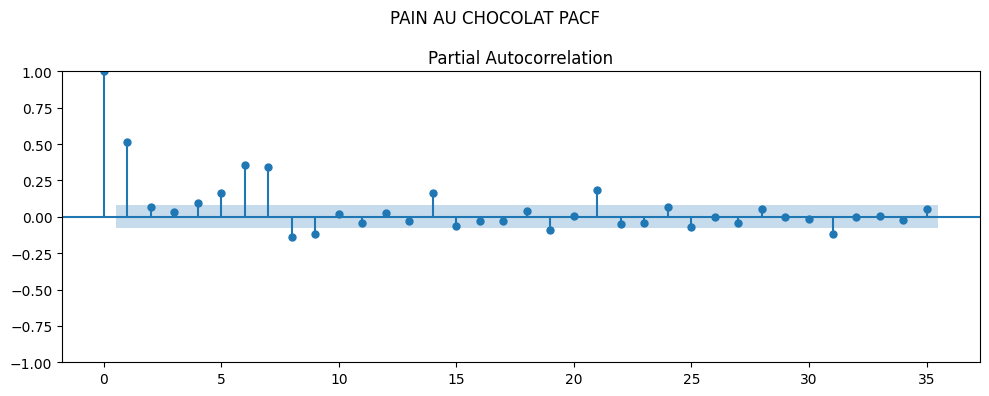

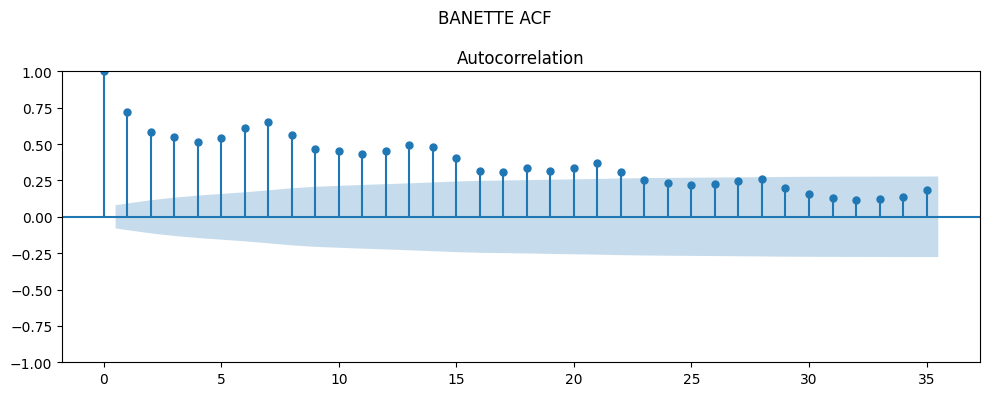

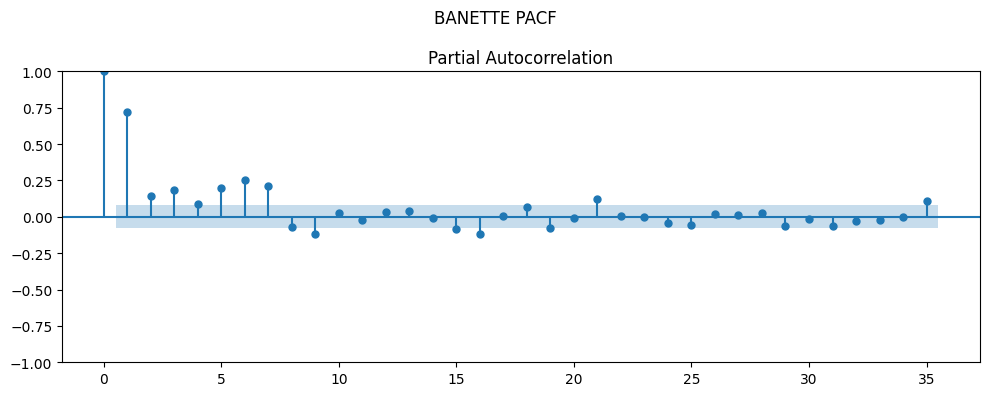

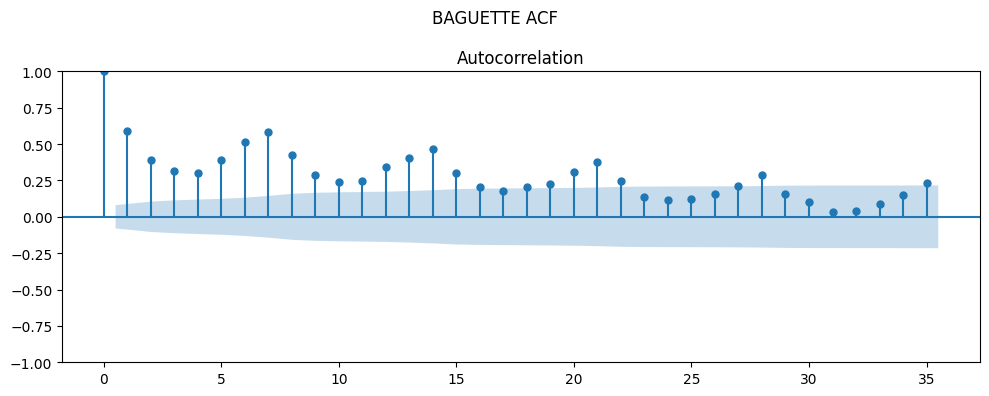

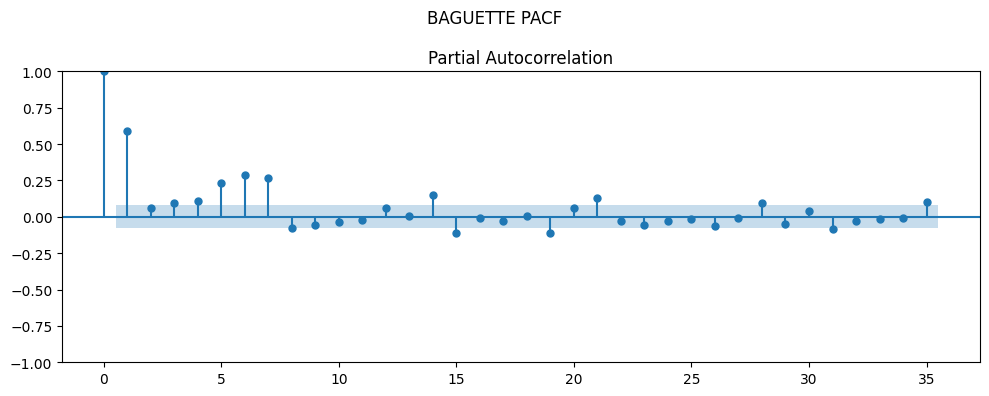

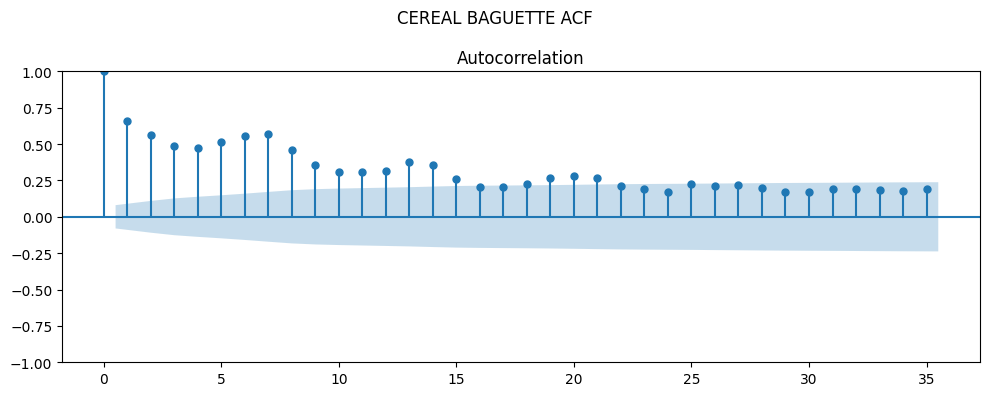

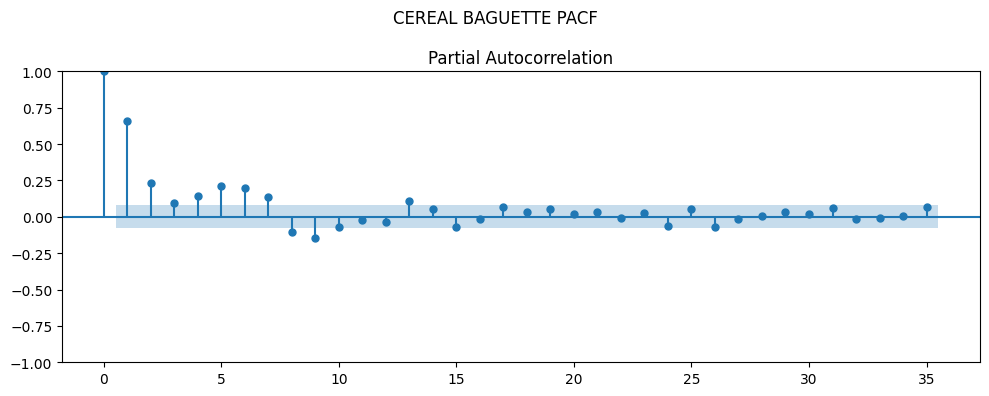

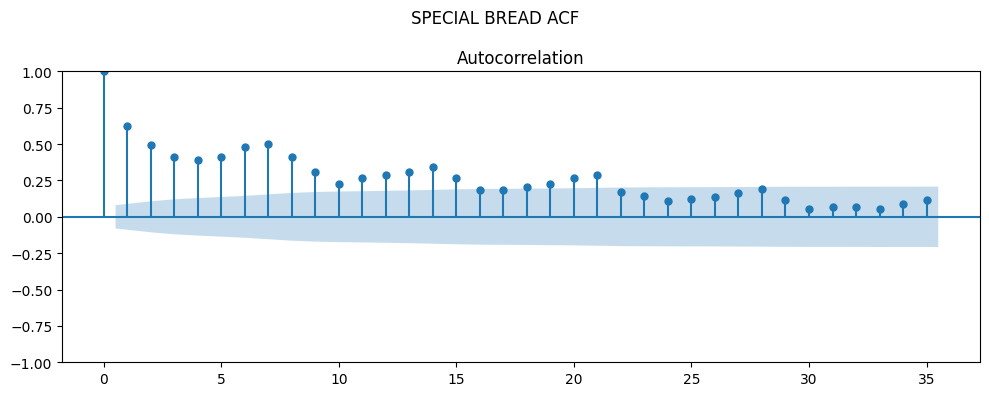

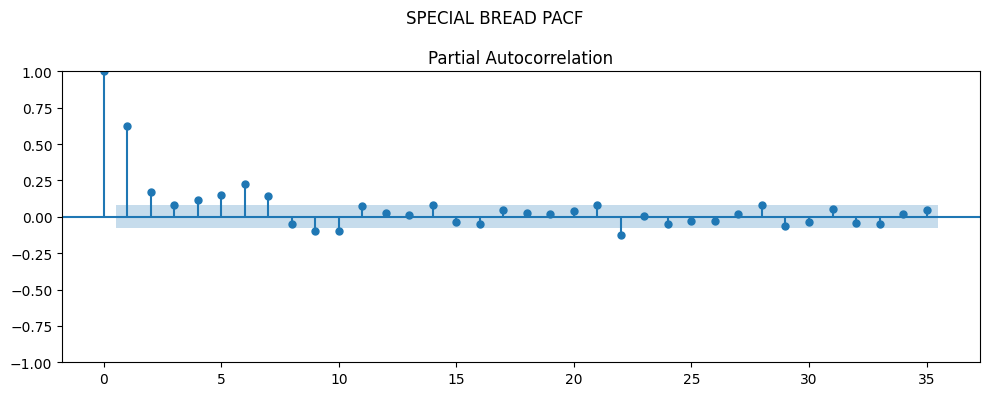

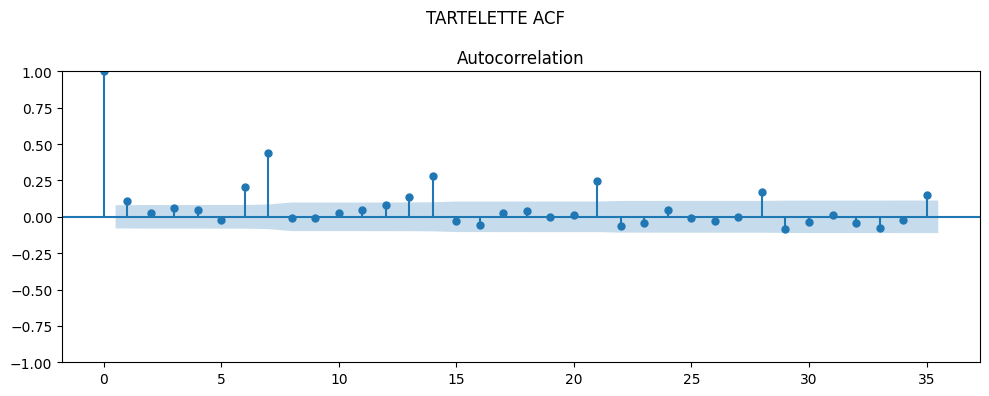

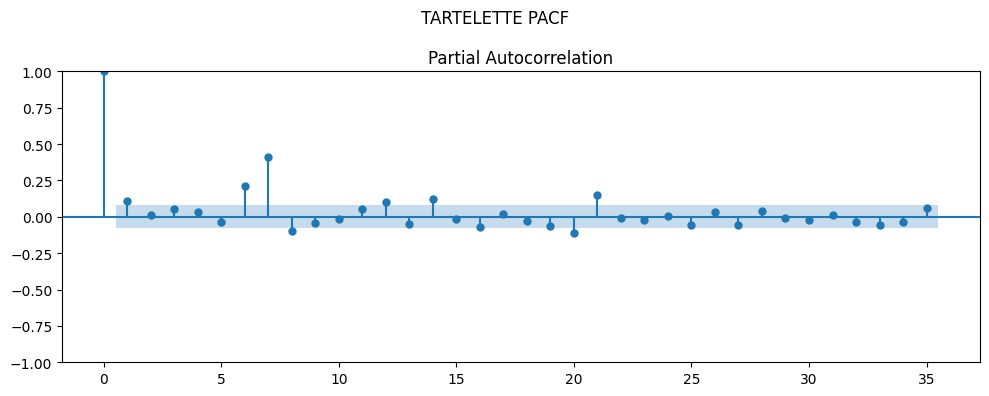

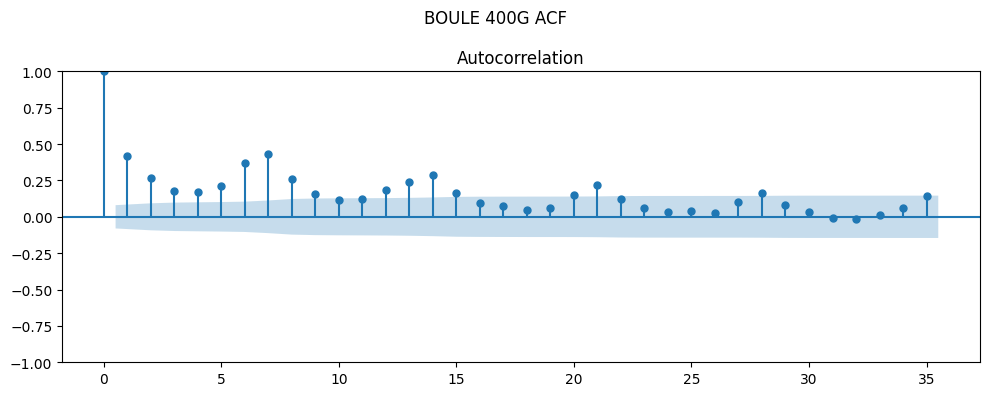

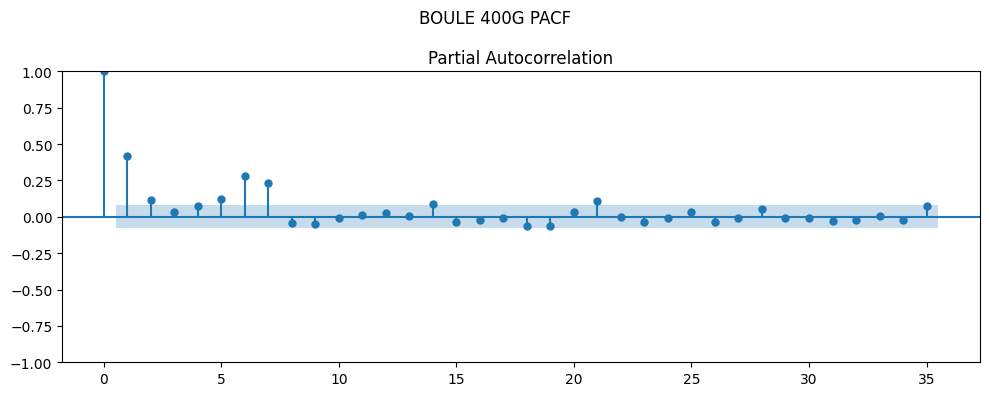

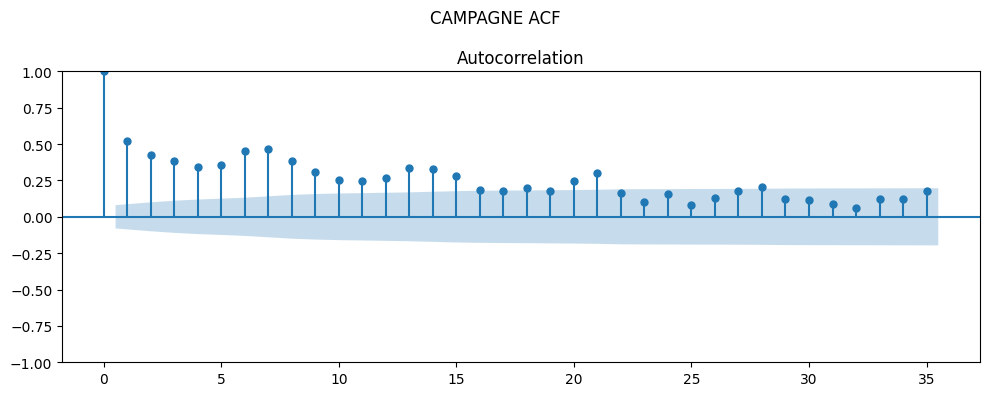

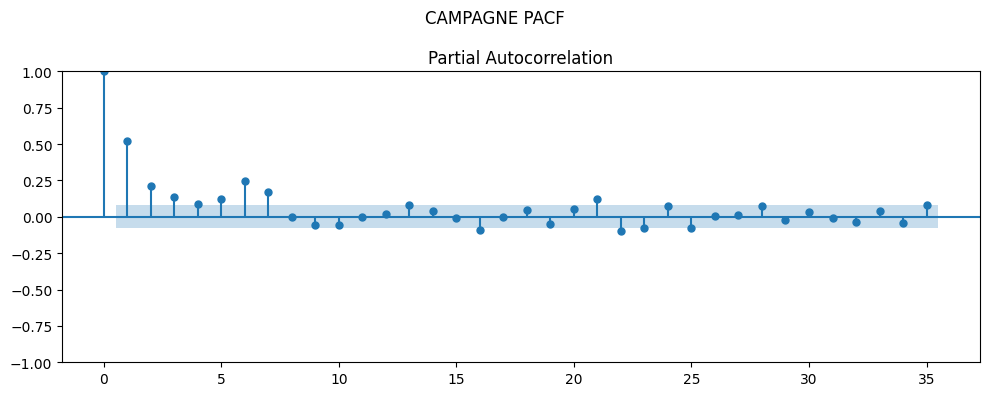

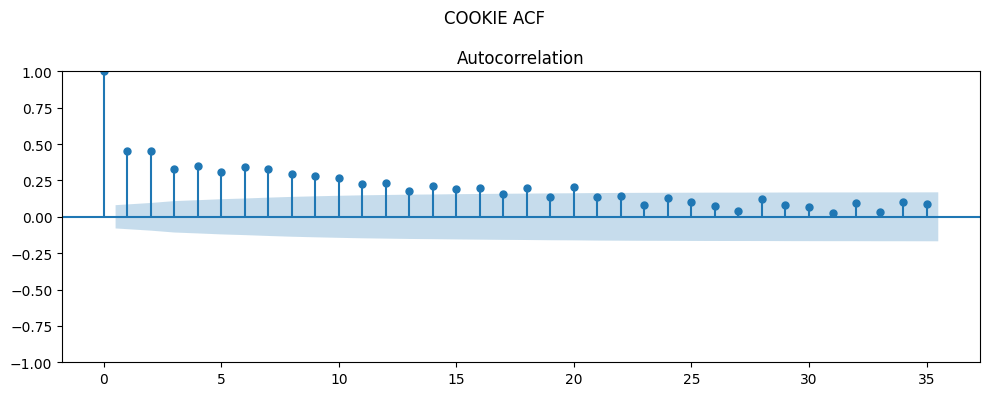

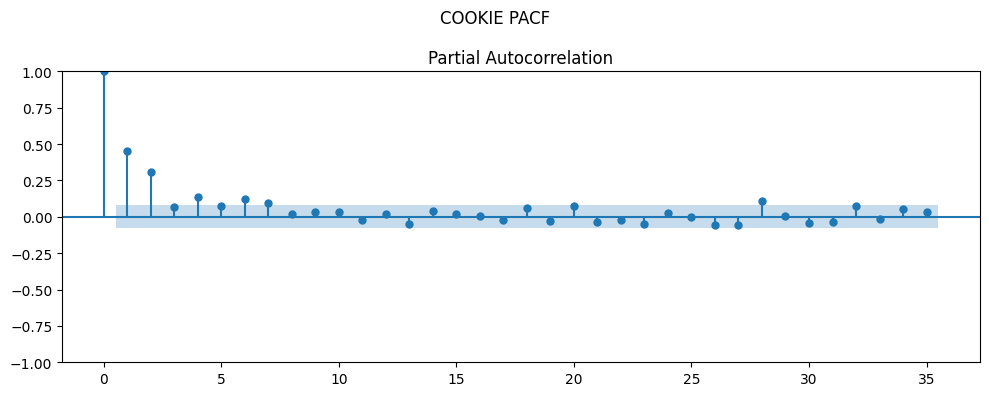

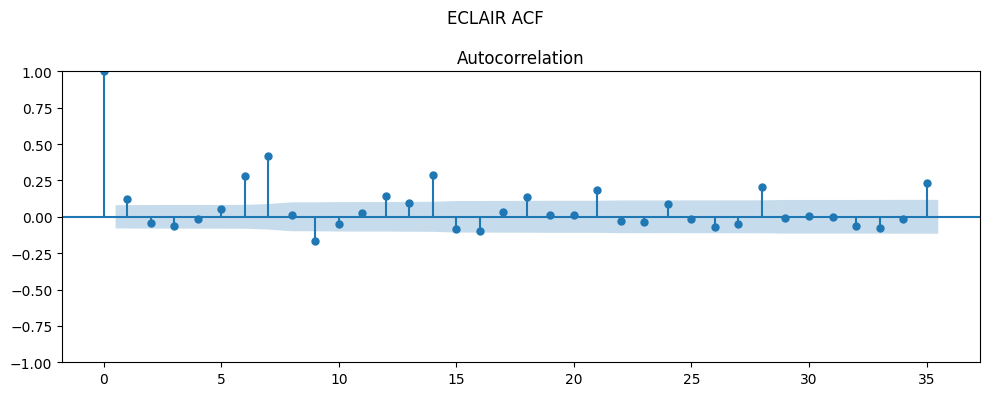

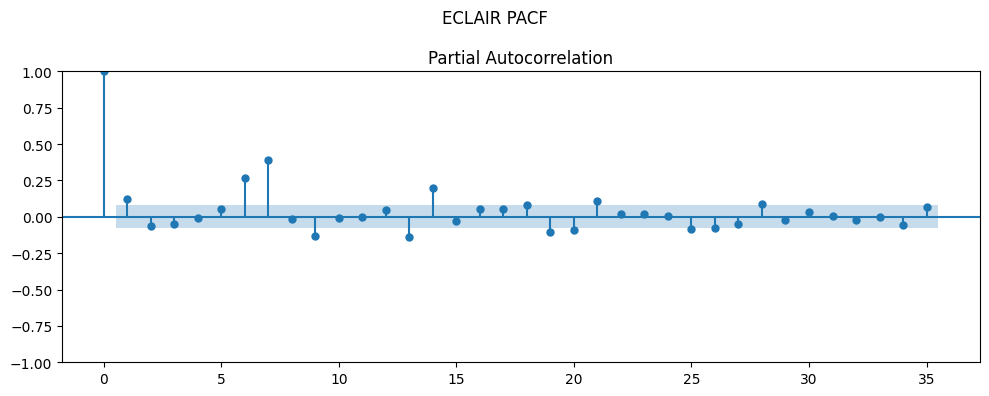

In [10]:
# ACF/PACF for one product
for p in top_products:
    series_for_acf = qty_ts[p]
    plot_acf_pacf(series_for_acf, lags=35, save_prefix=f"{p}")

In [11]:
# PYTHON — List exported figures
sorted(os.listdir(FIG_DIR))[:20]

['BAGUETTE_acf.png',
 'BAGUETTE_pacf.png',
 'BAGUETTE_quantity_timeseries.png',
 'BAGUETTE_rolling_means.png',
 'BAGUETTE_rolling_std30.png',
 'BAGUETTE_stl.png',
 'BAGUETTE_weekday_seasonality.png',
 'BANETTE_acf.png',
 'BANETTE_pacf.png',
 'BANETTE_quantity_timeseries.png',
 'BANETTE_rolling_means.png',
 'BANETTE_rolling_std30.png',
 'BANETTE_stl.png',
 'BANETTE_weekday_seasonality.png',
 'BOULE 400G_acf.png',
 'BOULE 400G_pacf.png',
 'BOULE 400G_quantity_timeseries.png',
 'BOULE 400G_rolling_means.png',
 'BOULE 400G_rolling_std30.png',
 'BOULE 400G_stl.png']

## 4) Rolling statistics

We overlay:
- the raw series
- 7-day rolling mean (short-term trend)
- 30-day rolling mean (medium-term trend)

And we also plot rolling standard deviation to see volatility changes.

In [12]:
# Rolling mean and rolling std plots
def plot_rolling_stats(series, name, filename_prefix):
    s = series.asfreq("D").fillna(0)  # ensure daily frequency

    roll7 = s.rolling(window=7, min_periods=1).mean()
    roll30 = s.rolling(window=30, min_periods=1).mean()
    roll_std_30 = s.rolling(window=30, min_periods=1).std()

    # Plot: raw + rolling means
    fig1 = plt.figure(figsize=(12, 4))
    plt.plot(s.index, s.values, label="Daily", alpha=0.5)
    plt.plot(roll7.index, roll7.values, label="Rolling mean (7d)")
    plt.plot(roll30.index, roll30.values, label="Rolling mean (30d)")
    plt.title(f"{name} — Daily series with rolling means")
    plt.xlabel("Date")
    plt.ylabel("Quantity")
    plt.legend()
    plt.tight_layout()
    save_show(fig1, f"{filename_prefix}_rolling_means.png")

    # Plot: rolling volatility
    fig2 = plt.figure(figsize=(12, 4))
    plt.plot(roll_std_30.index, roll_std_30.values)
    plt.title(f"{name} — Rolling volatility (30d std)")
    plt.xlabel("Date")
    plt.ylabel("Std (30d)")
    plt.tight_layout()
    save_show(fig2, f"{filename_prefix}_rolling_std30.png")

Saved: reports/figures/TRADITIONAL BAGUETTE_rolling_means.png


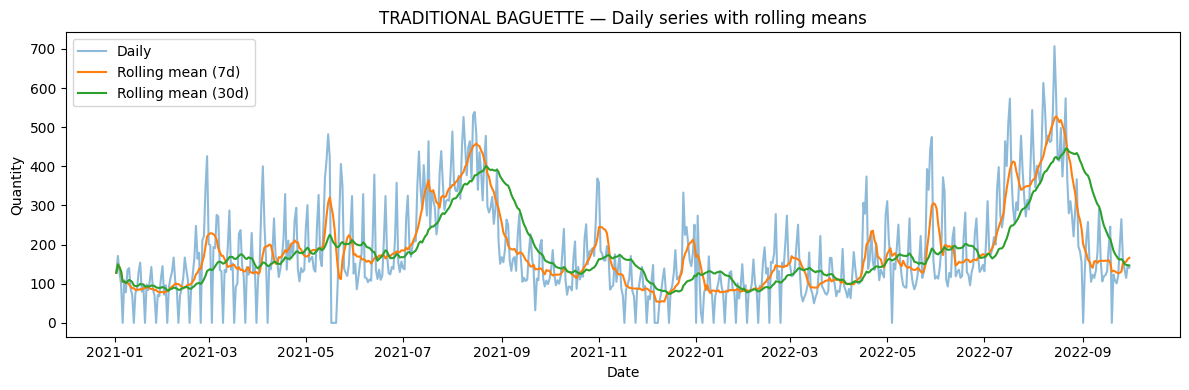

Saved: reports/figures/TRADITIONAL BAGUETTE_rolling_std30.png


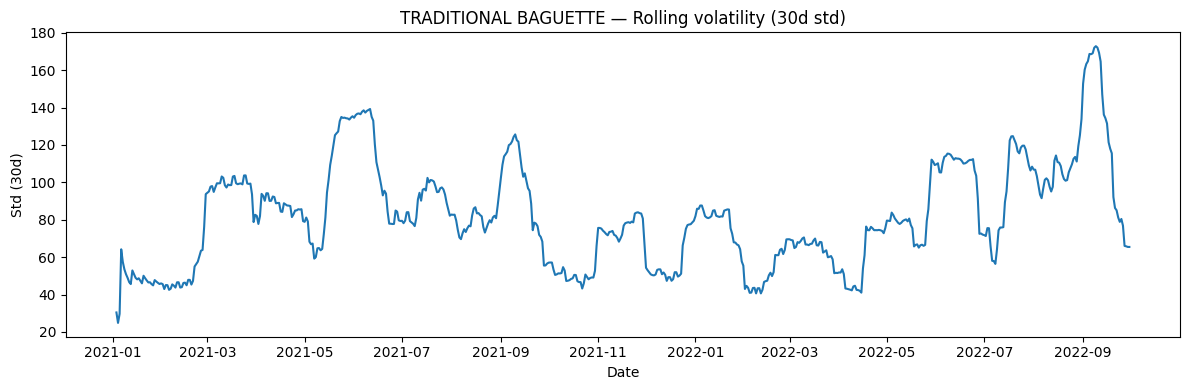

Saved: reports/figures/CROISSANT_rolling_means.png


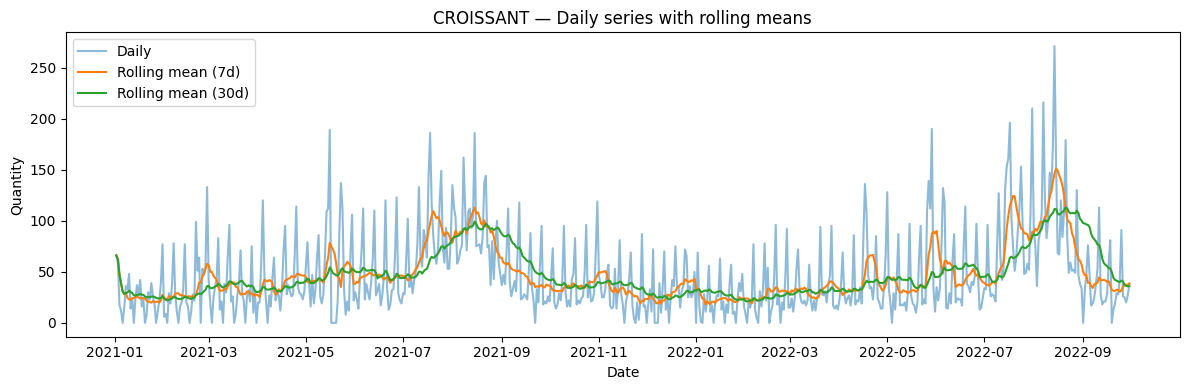

Saved: reports/figures/CROISSANT_rolling_std30.png


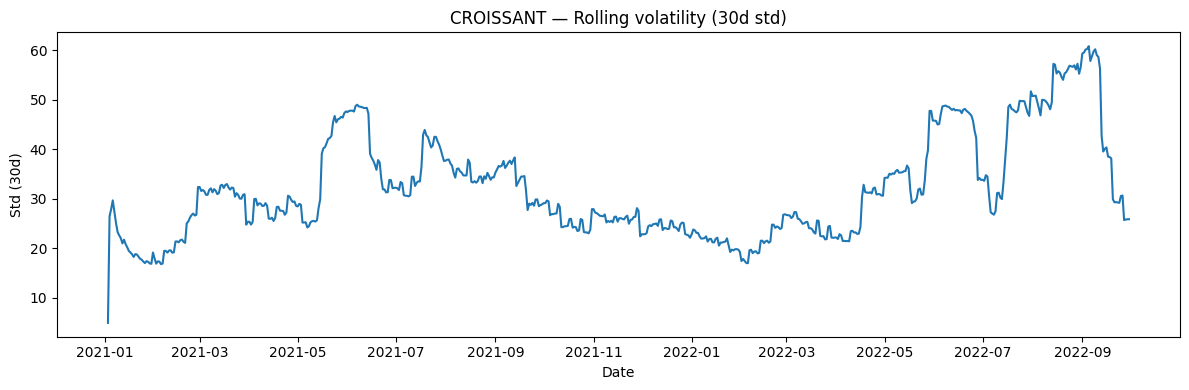

Saved: reports/figures/PAIN AU CHOCOLAT_rolling_means.png


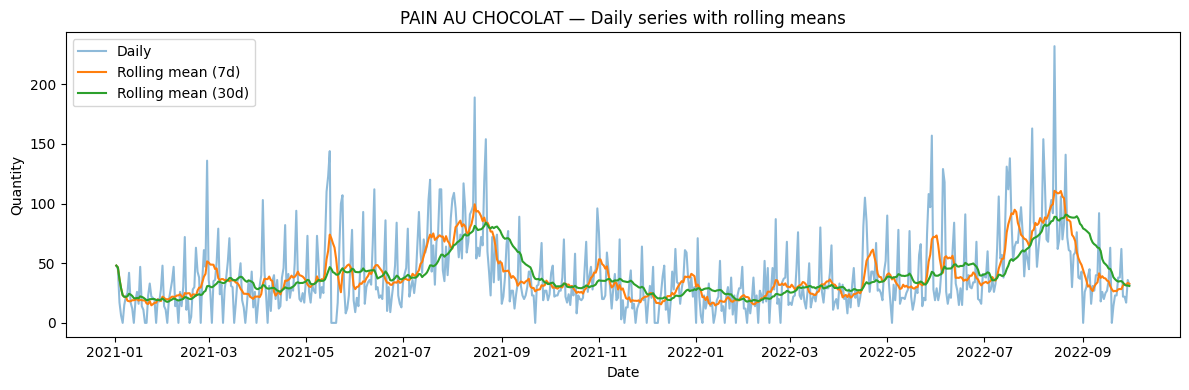

Saved: reports/figures/PAIN AU CHOCOLAT_rolling_std30.png


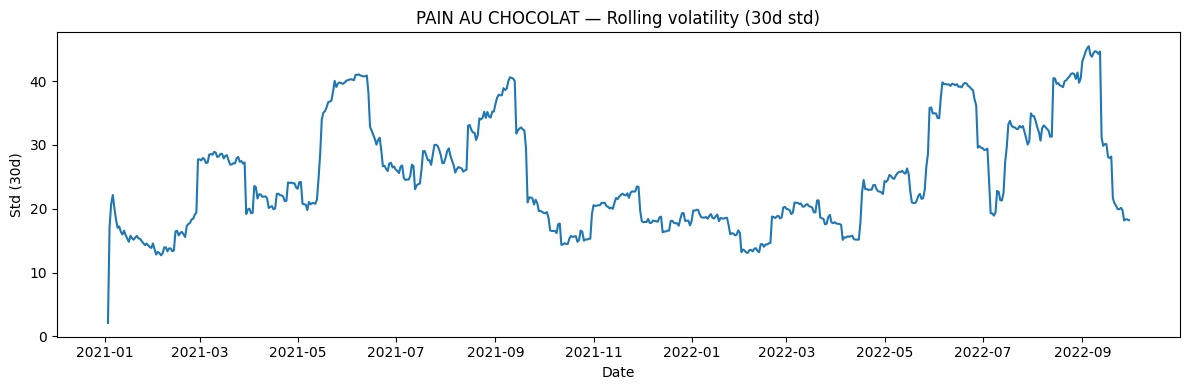

Saved: reports/figures/BANETTE_rolling_means.png


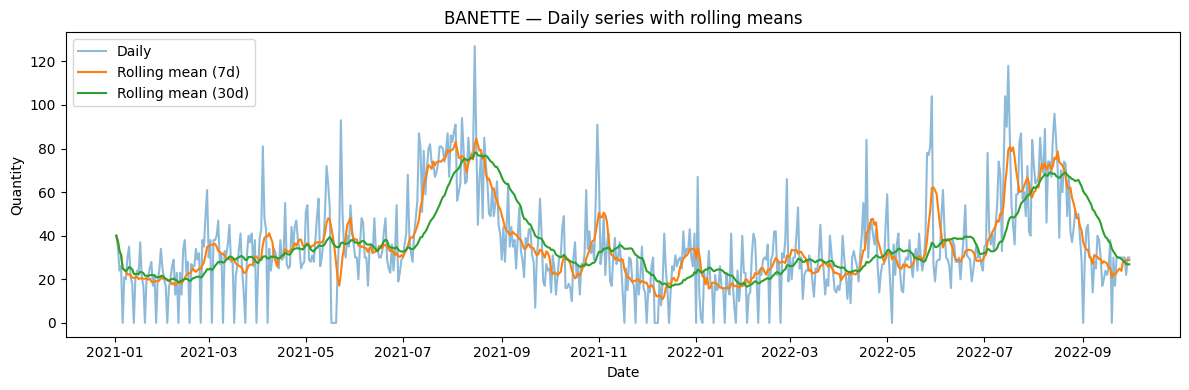

Saved: reports/figures/BANETTE_rolling_std30.png


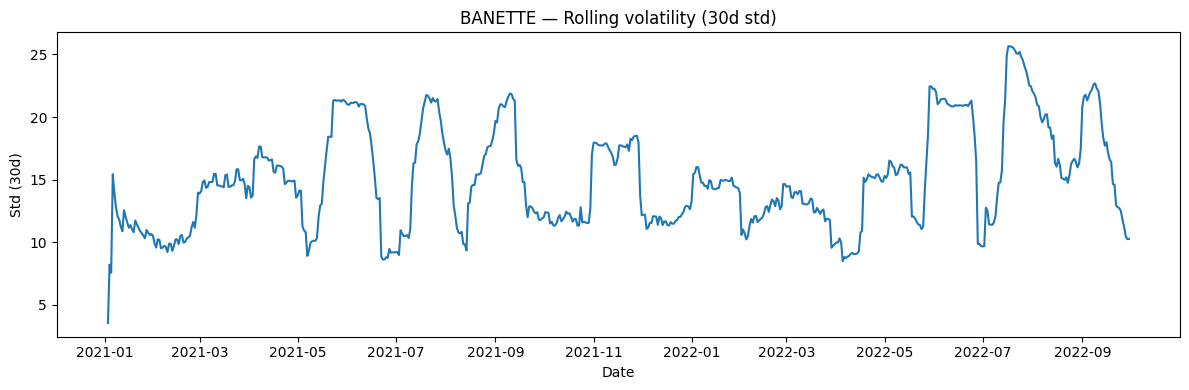

Saved: reports/figures/BAGUETTE_rolling_means.png


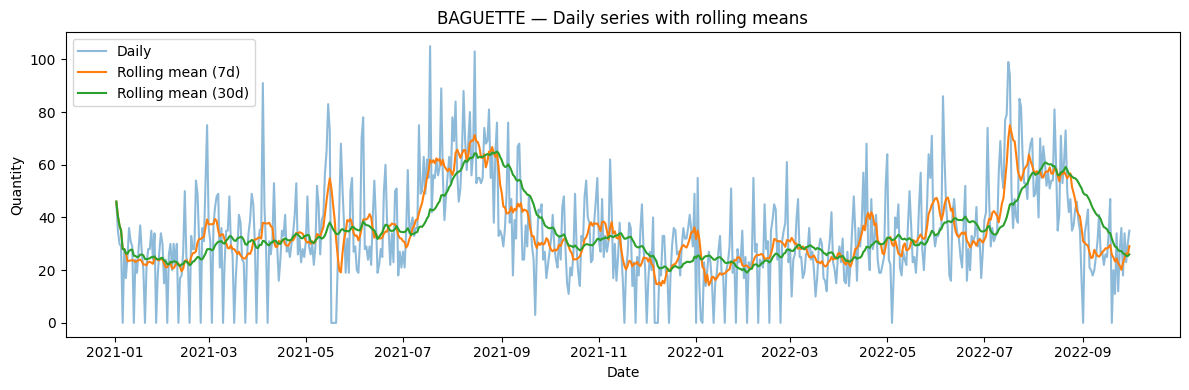

Saved: reports/figures/BAGUETTE_rolling_std30.png


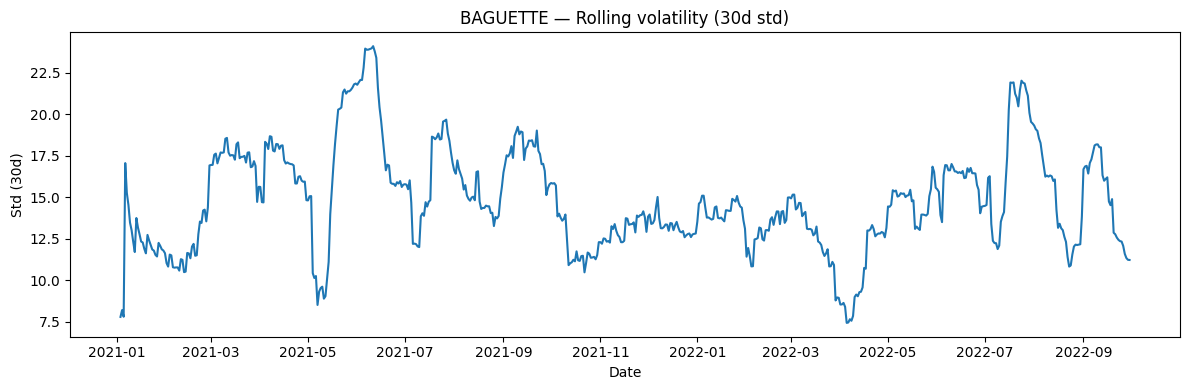

Saved: reports/figures/CEREAL BAGUETTE_rolling_means.png


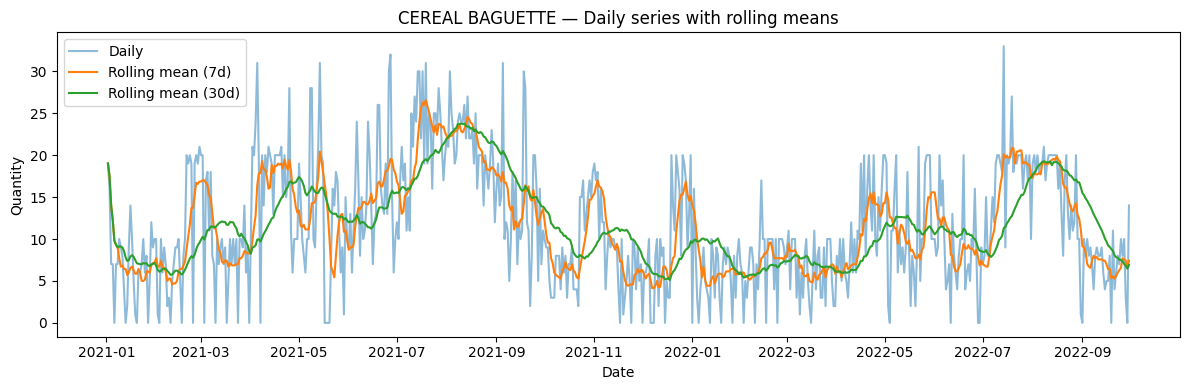

Saved: reports/figures/CEREAL BAGUETTE_rolling_std30.png


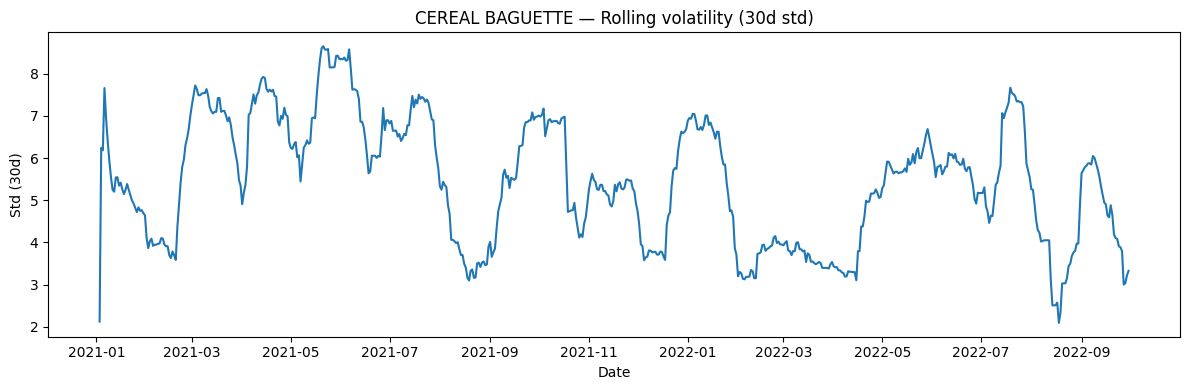

Saved: reports/figures/SPECIAL BREAD_rolling_means.png


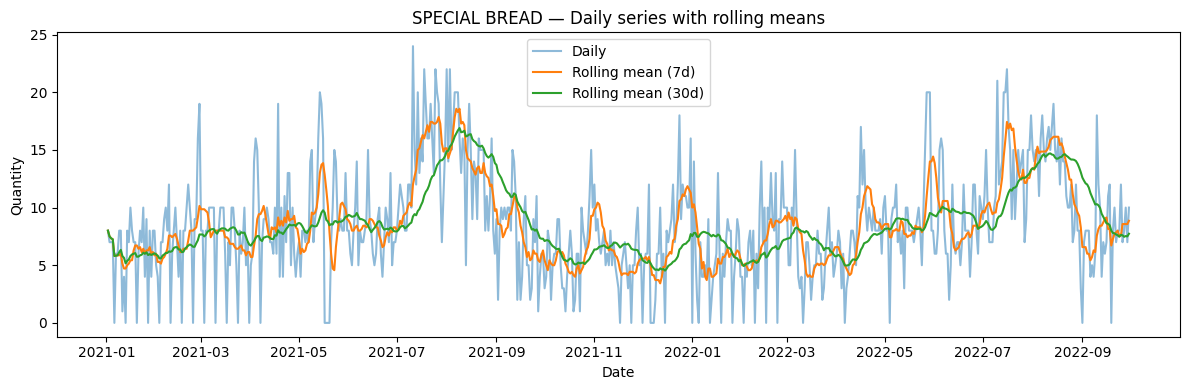

Saved: reports/figures/SPECIAL BREAD_rolling_std30.png


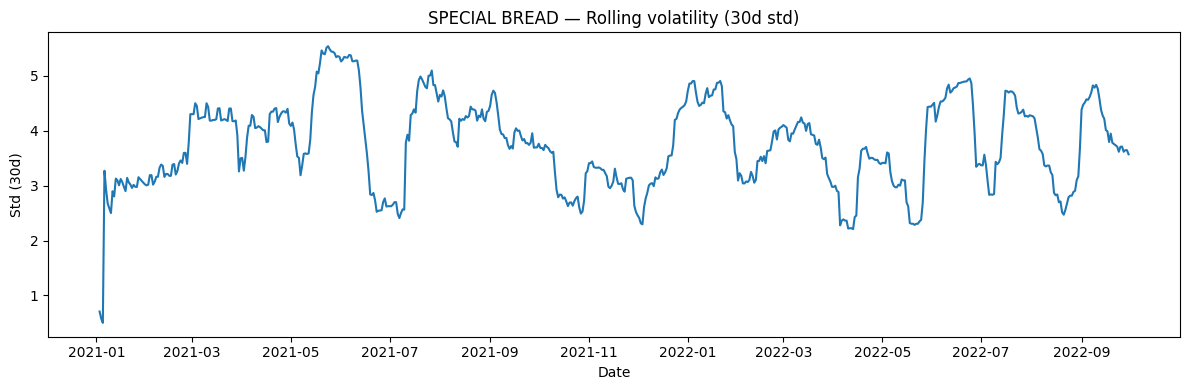

Saved: reports/figures/TARTELETTE_rolling_means.png


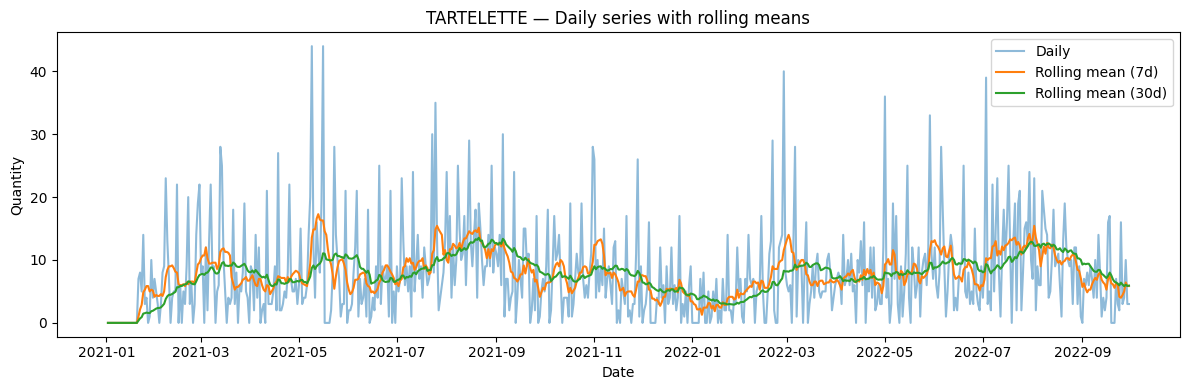

Saved: reports/figures/TARTELETTE_rolling_std30.png


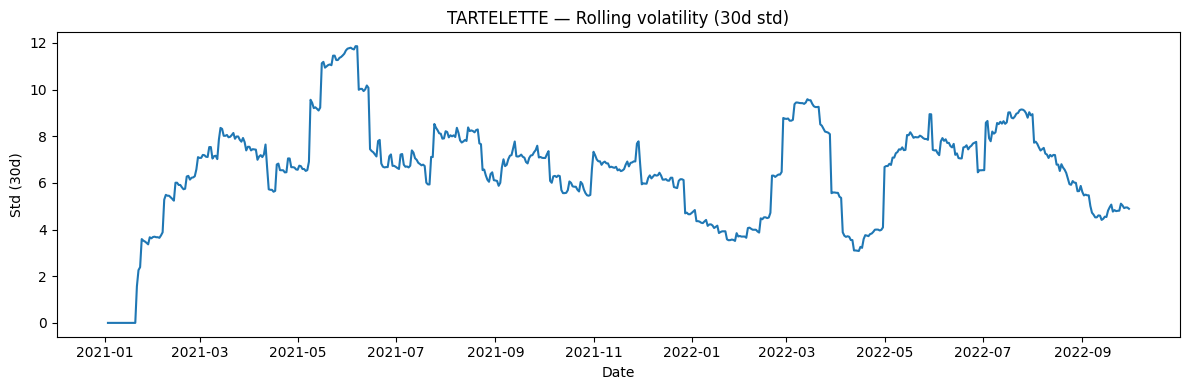

Saved: reports/figures/BOULE 400G_rolling_means.png


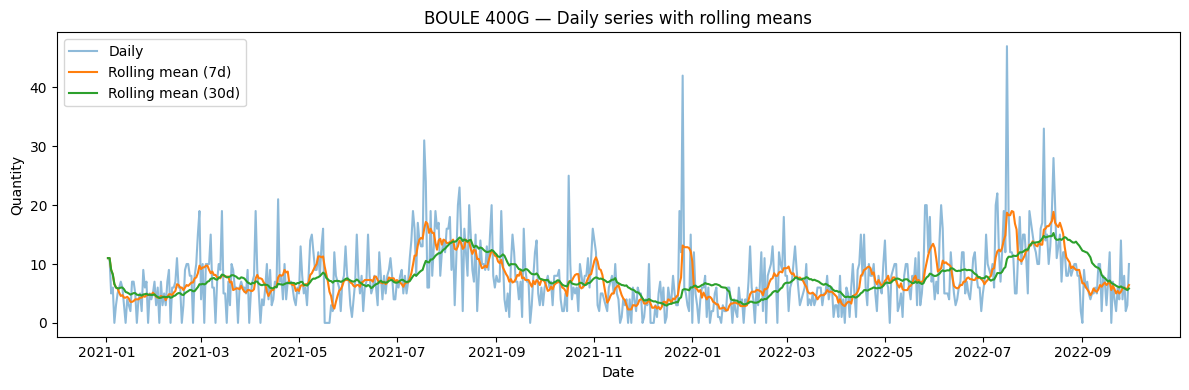

Saved: reports/figures/BOULE 400G_rolling_std30.png


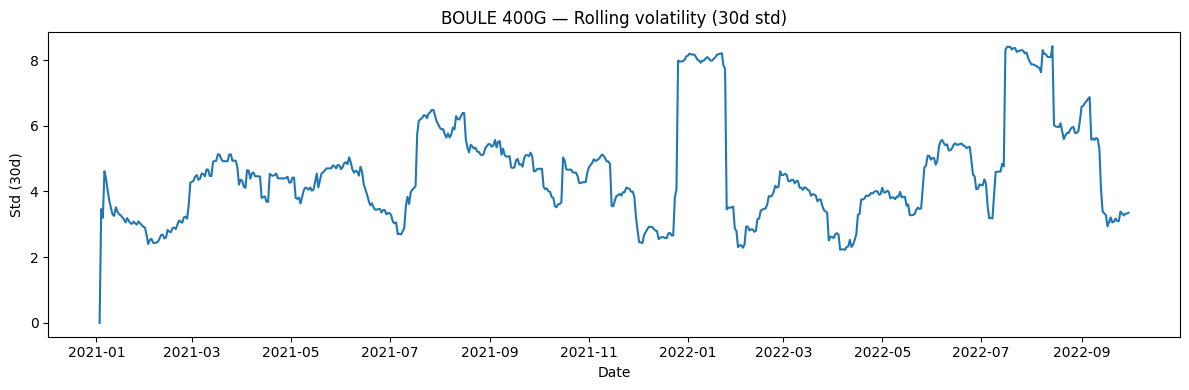

Saved: reports/figures/CAMPAGNE_rolling_means.png


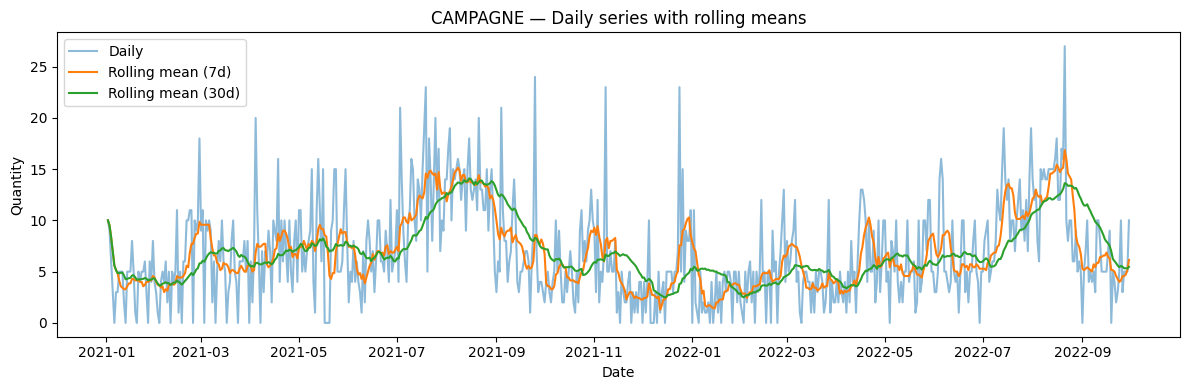

Saved: reports/figures/CAMPAGNE_rolling_std30.png


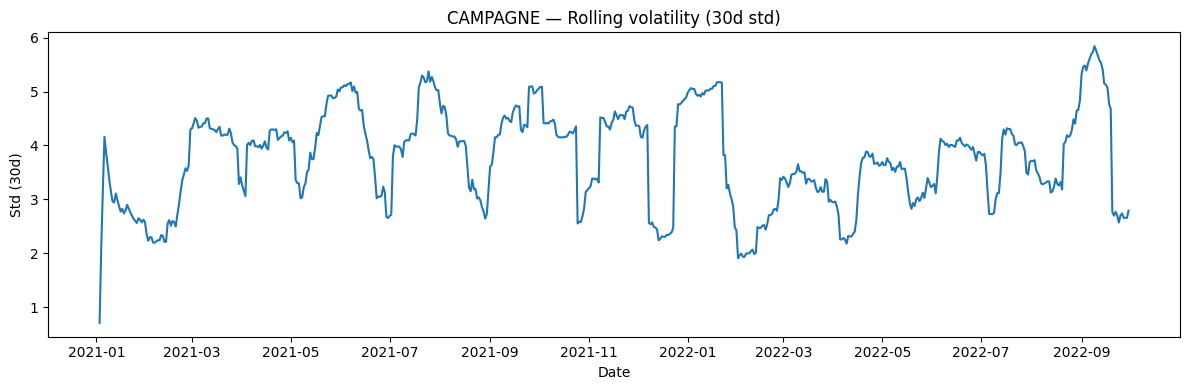

Saved: reports/figures/COOKIE_rolling_means.png


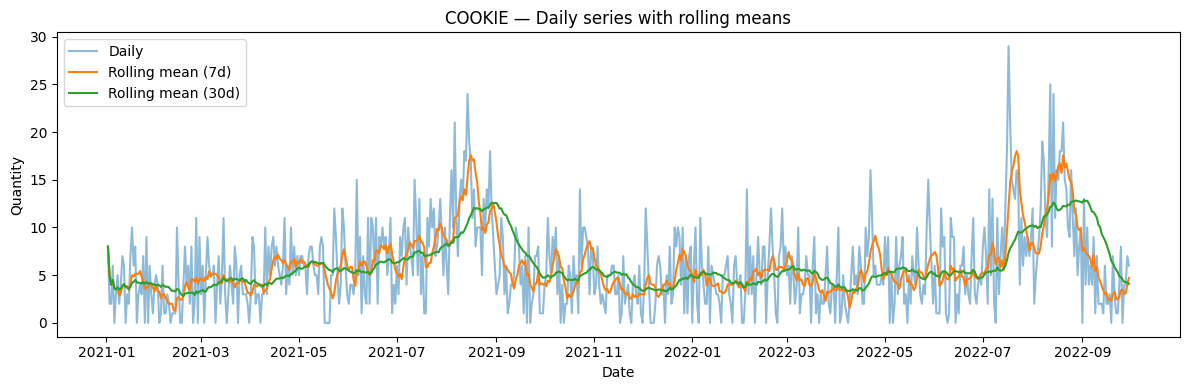

Saved: reports/figures/COOKIE_rolling_std30.png


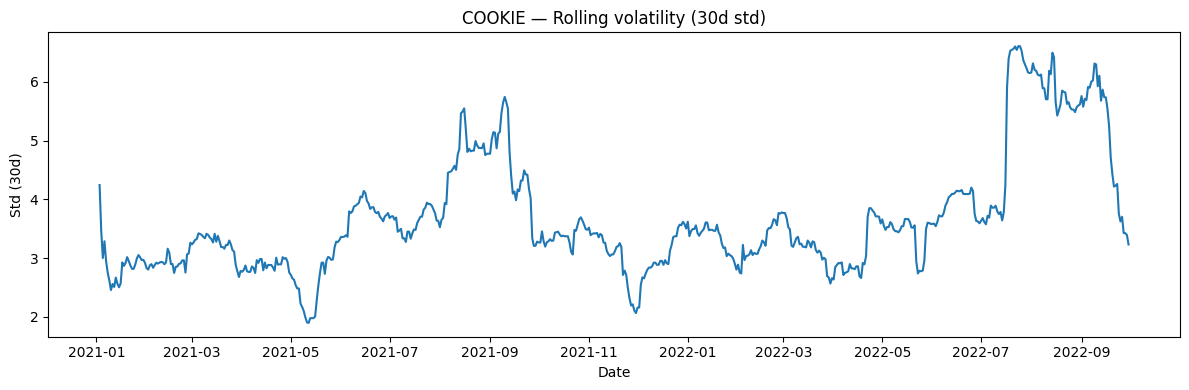

Saved: reports/figures/ECLAIR_rolling_means.png


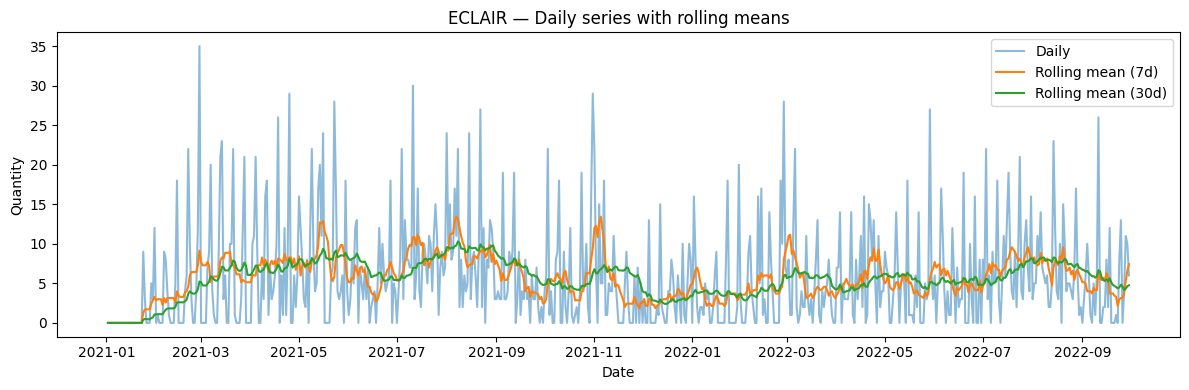

Saved: reports/figures/ECLAIR_rolling_std30.png


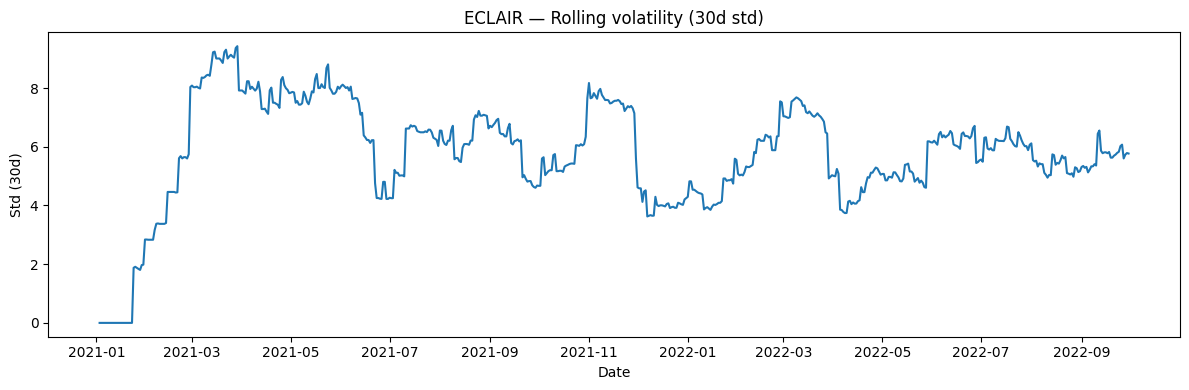

In [13]:
# Apply rolling stats plots to one main product
for p in top_products:
    plot_rolling_stats(qty_ts[p], name=f"{p}", filename_prefix=f"{p}")

## 5) STL decomposition

STL decomposes the series into:
- Trend: long-term movement
- Seasonal: repeating pattern (here weekly)
- Residual: noise / unexplained part

We will use a weekly period = 7 (daily data with weekday seasonality).


Saved: reports/figures/TRADITIONAL BAGUETTE_stl.png


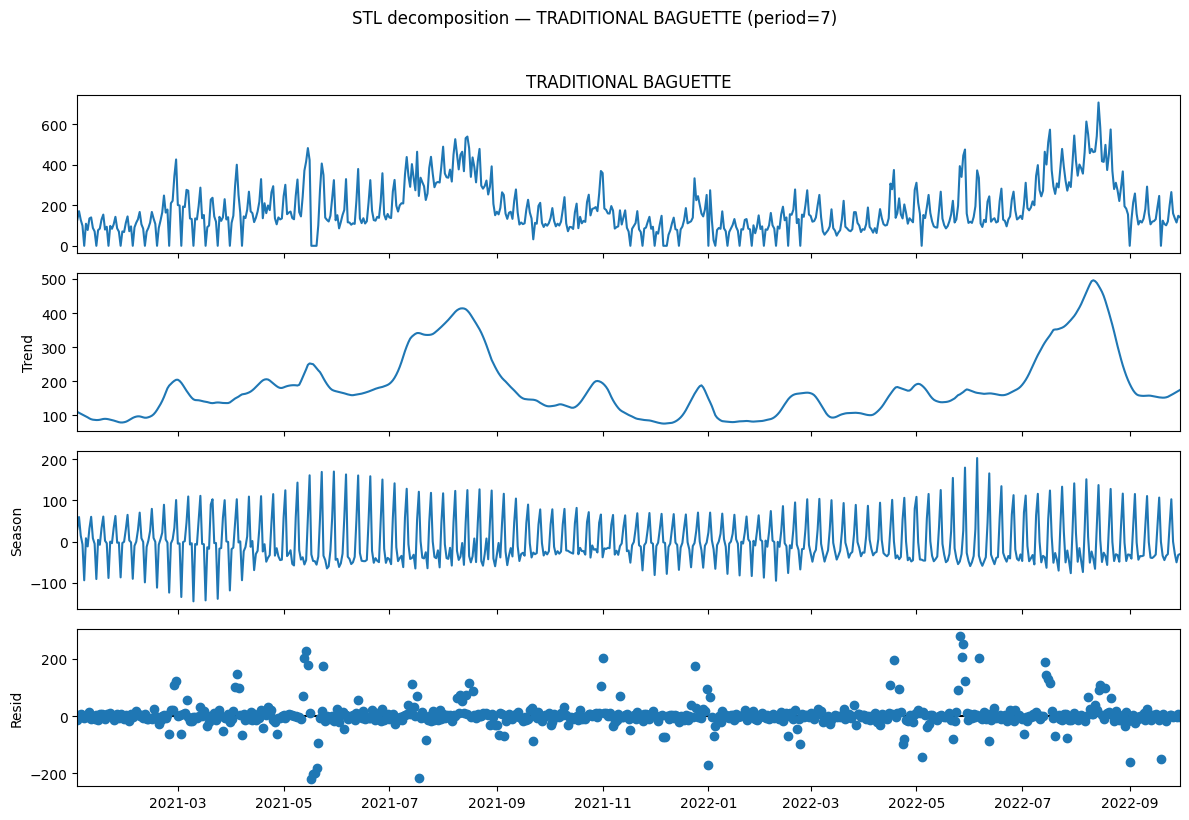

Saved: reports/figures/CROISSANT_stl.png


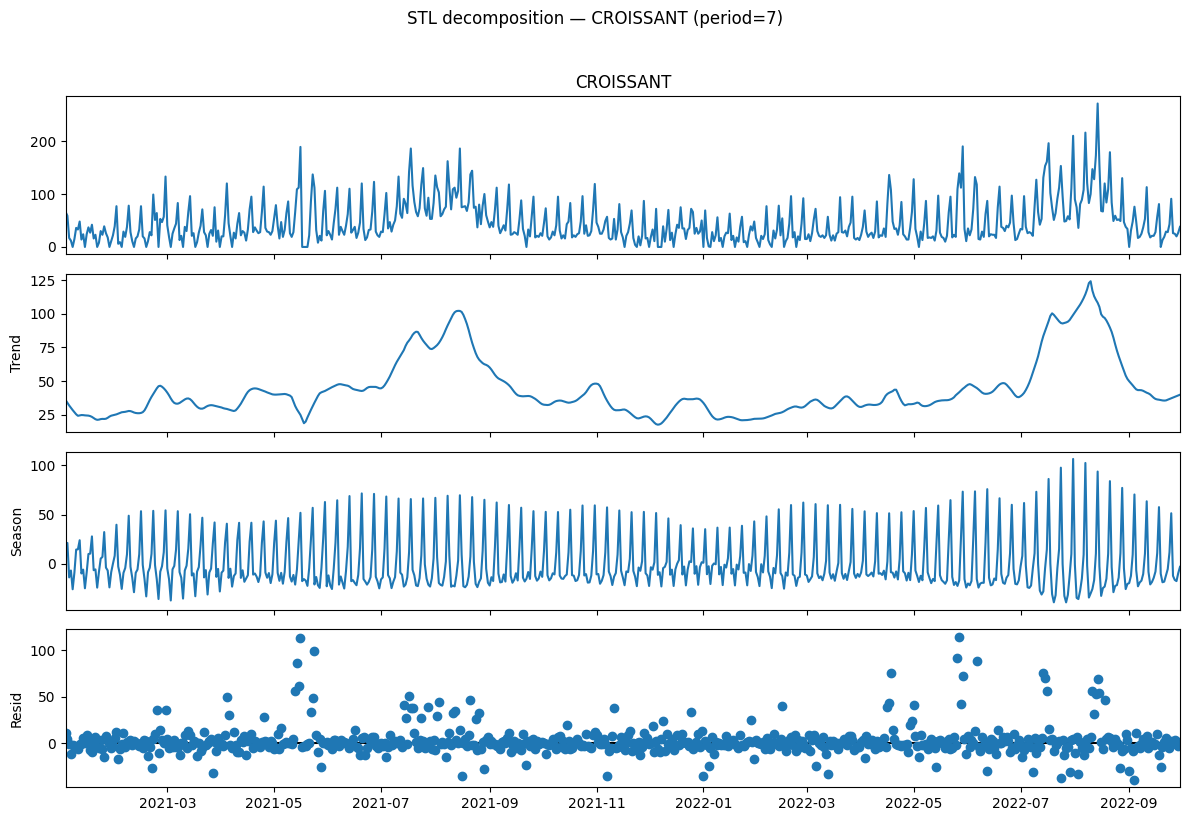

Saved: reports/figures/PAIN AU CHOCOLAT_stl.png


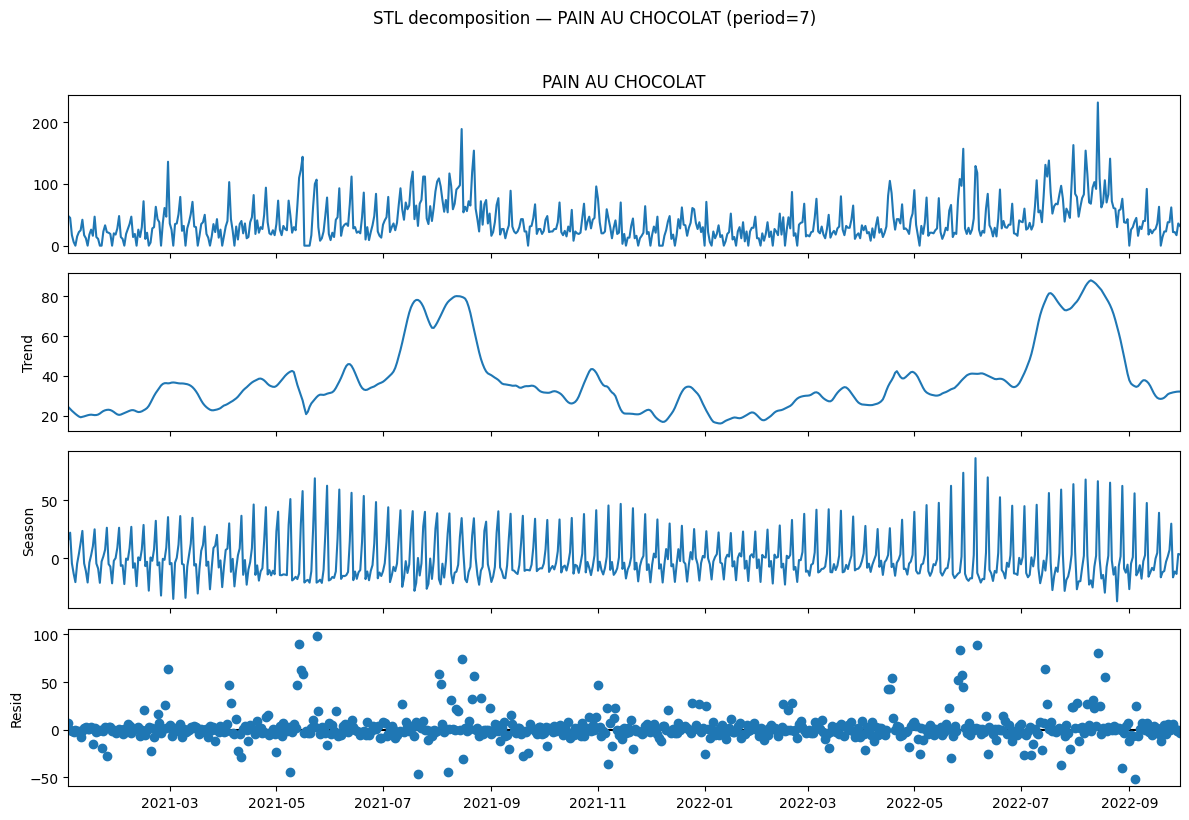

Saved: reports/figures/BANETTE_stl.png


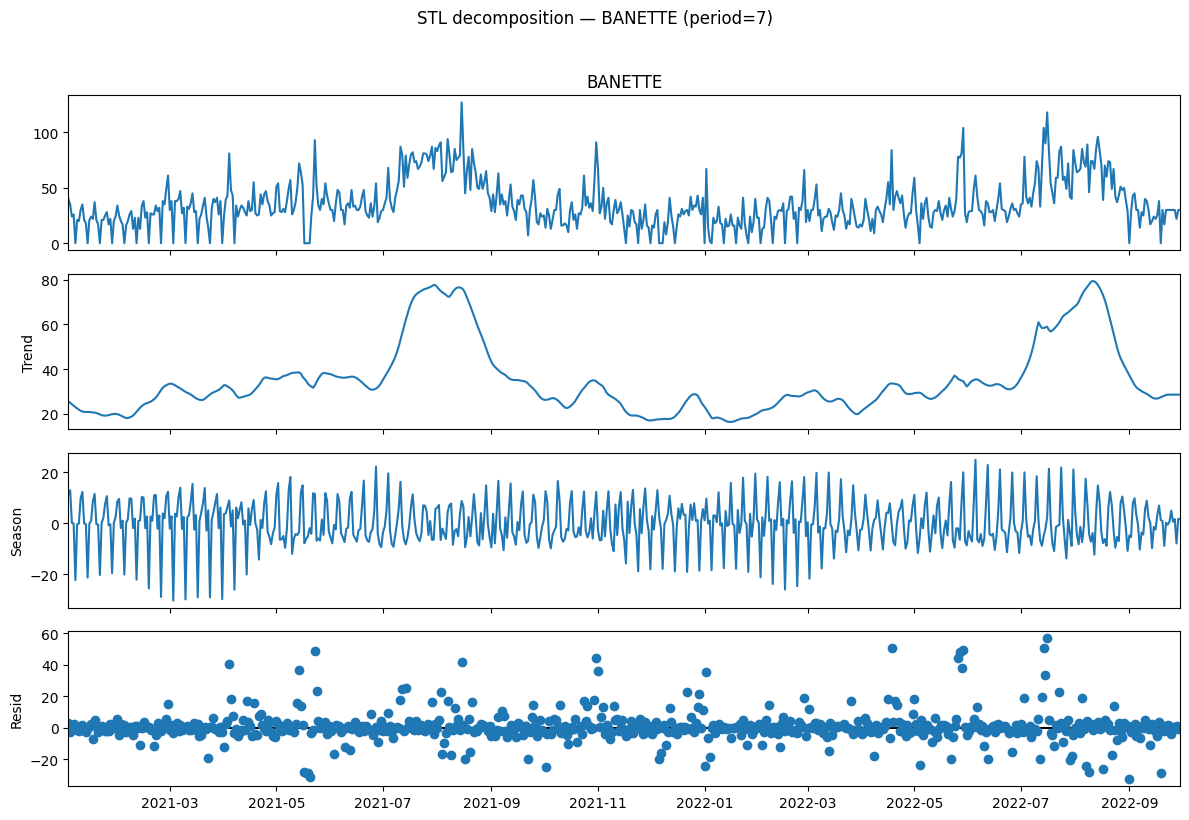

Saved: reports/figures/BAGUETTE_stl.png


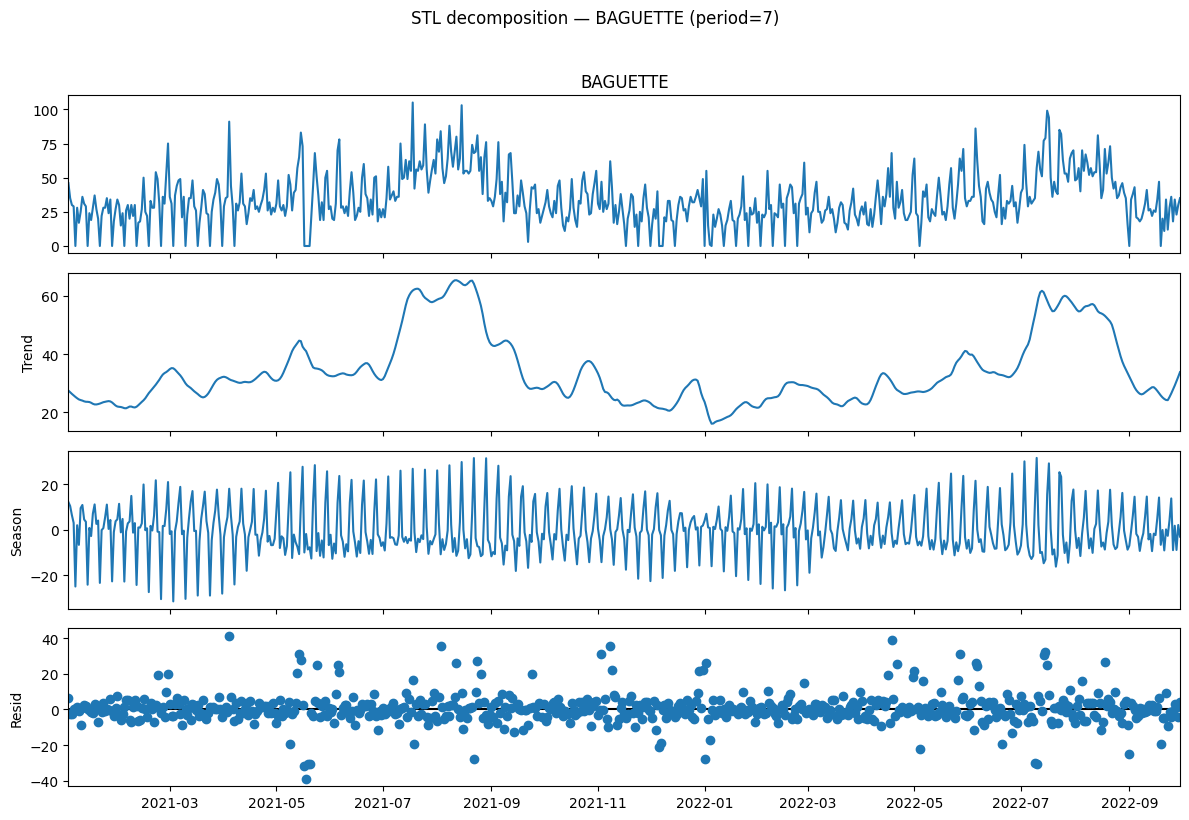

Saved: reports/figures/CEREAL BAGUETTE_stl.png


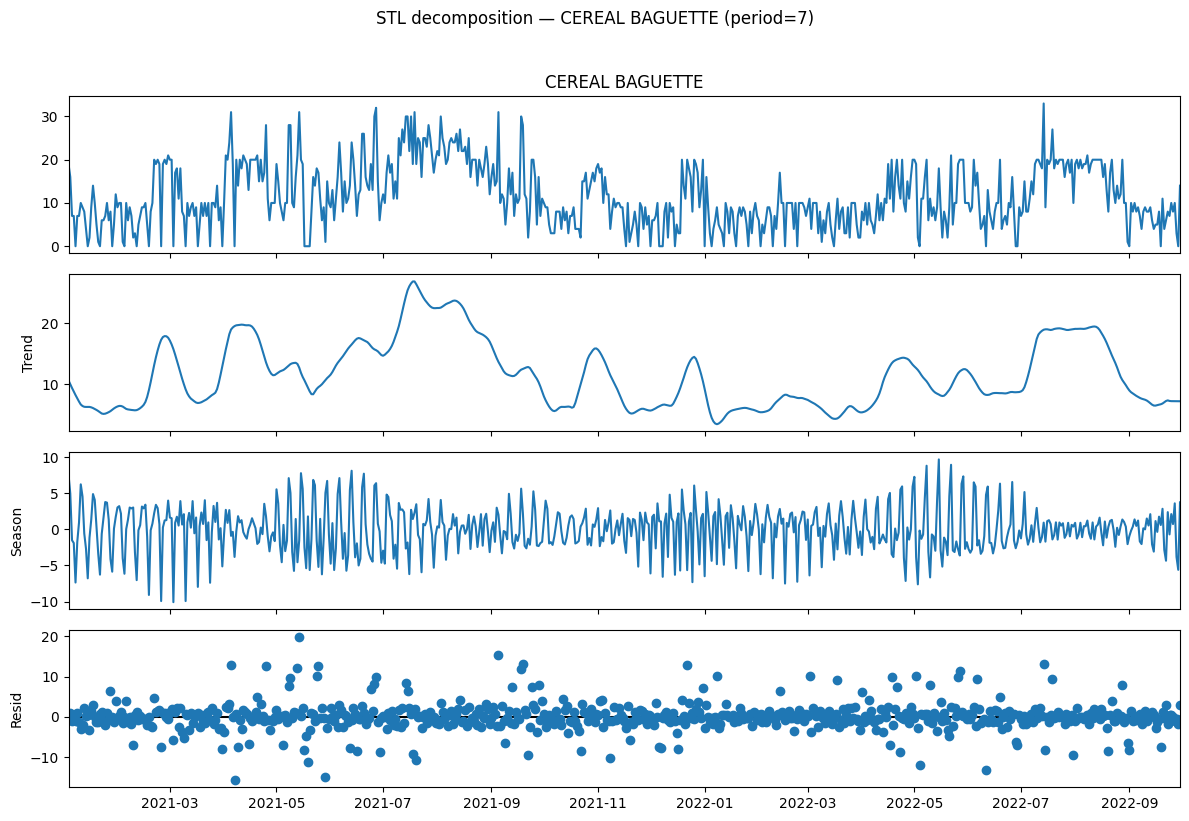

Saved: reports/figures/SPECIAL BREAD_stl.png


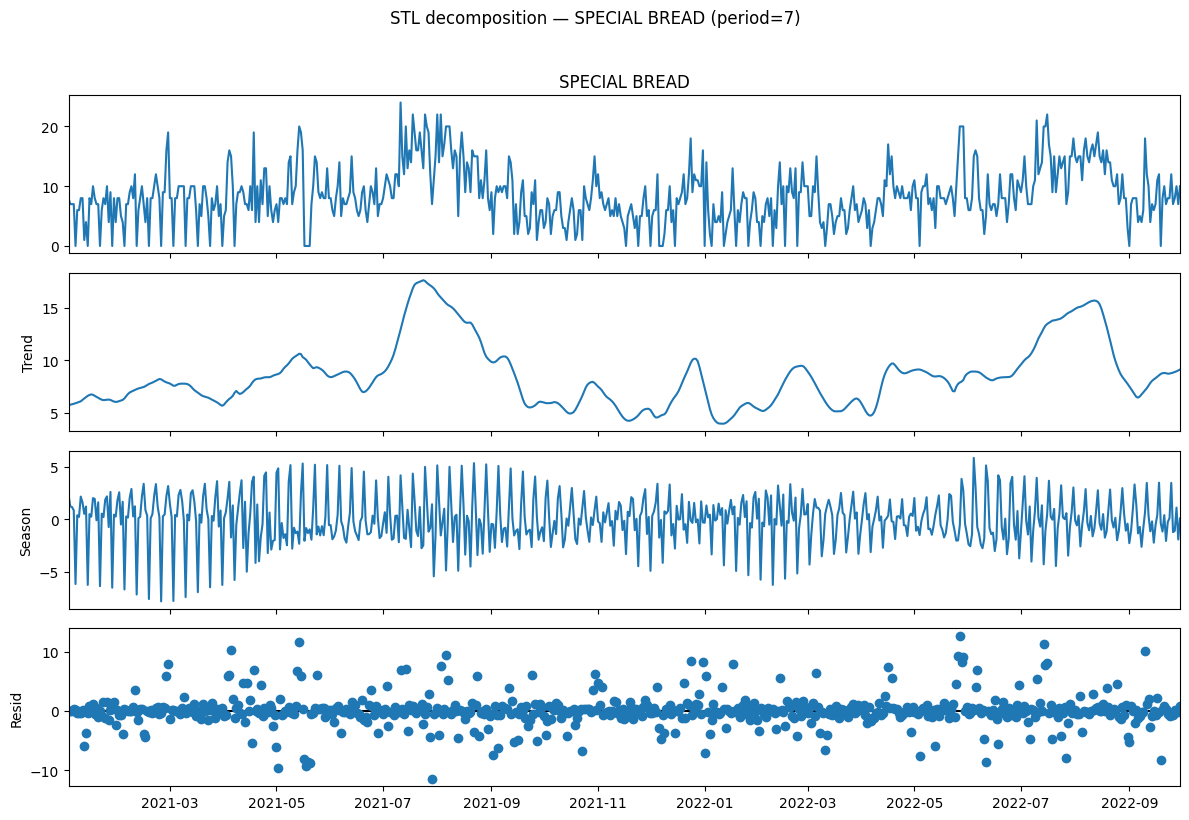

Saved: reports/figures/TARTELETTE_stl.png


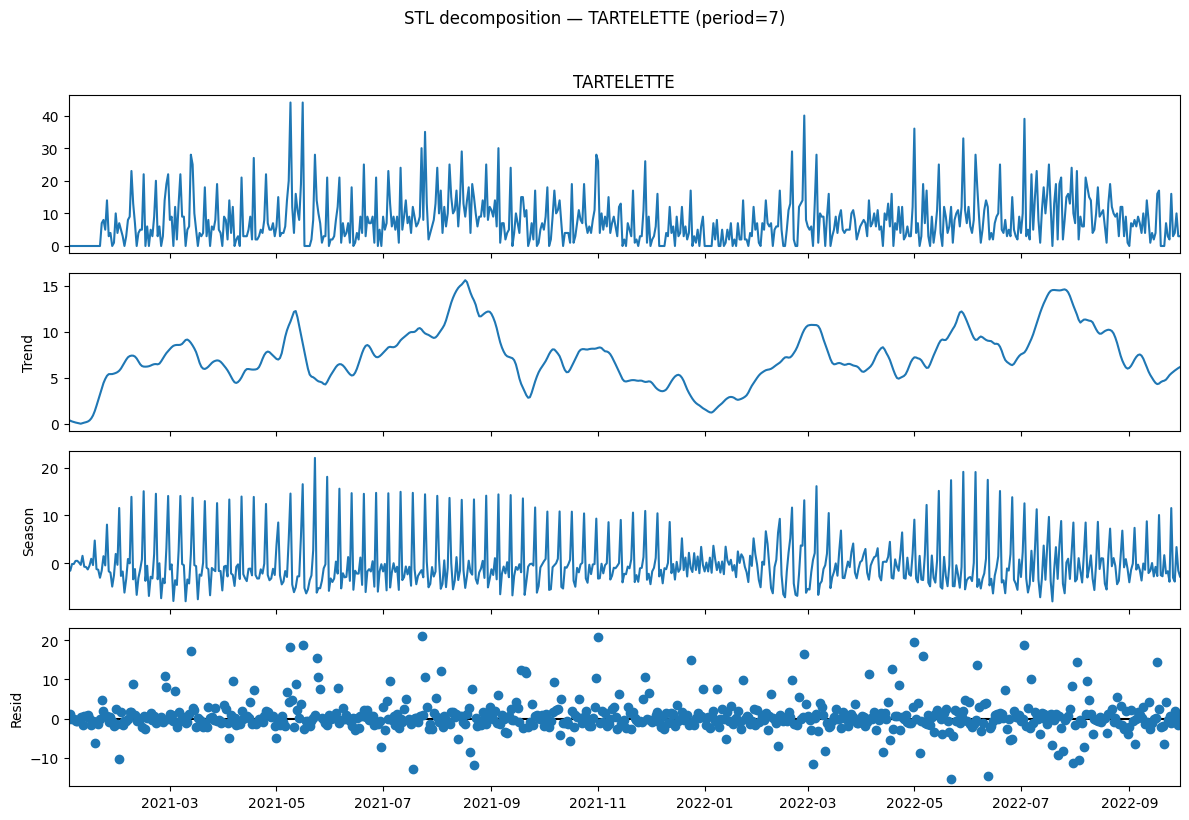

Saved: reports/figures/BOULE 400G_stl.png


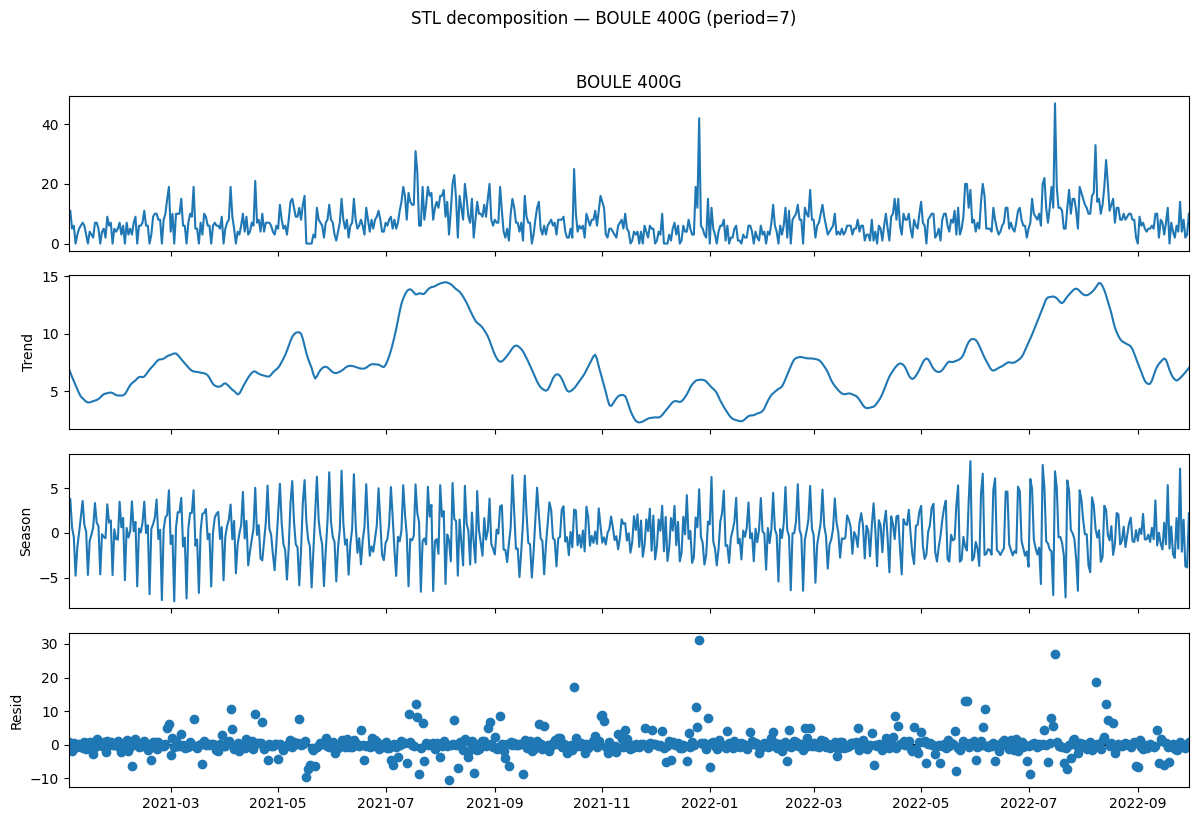

Saved: reports/figures/CAMPAGNE_stl.png


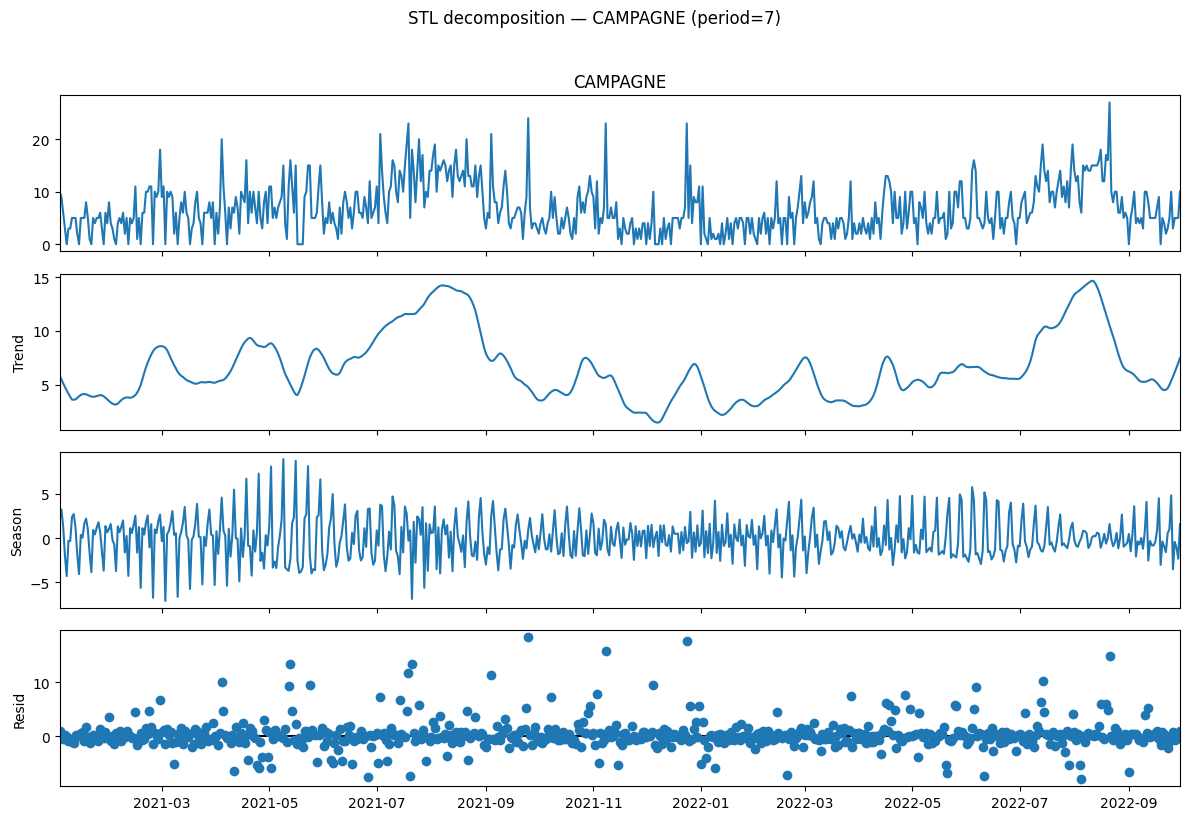

Saved: reports/figures/COOKIE_stl.png


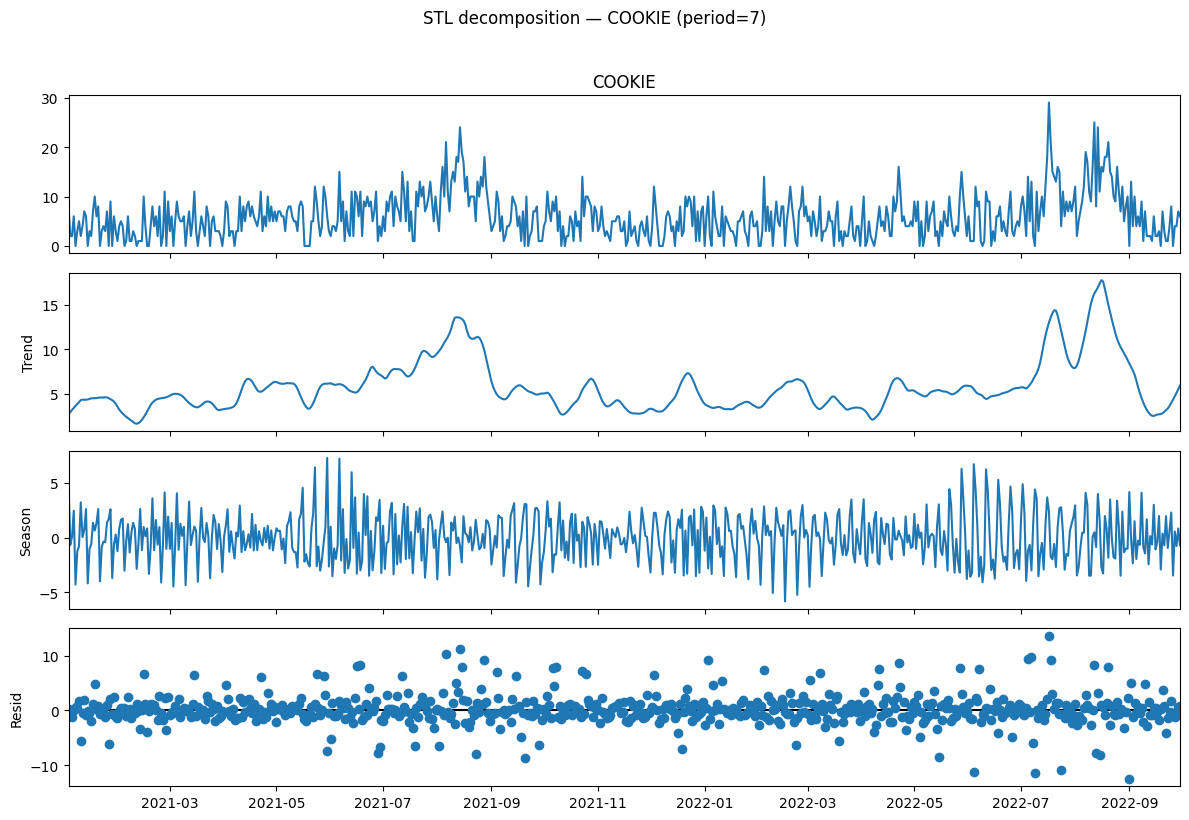

Saved: reports/figures/ECLAIR_stl.png


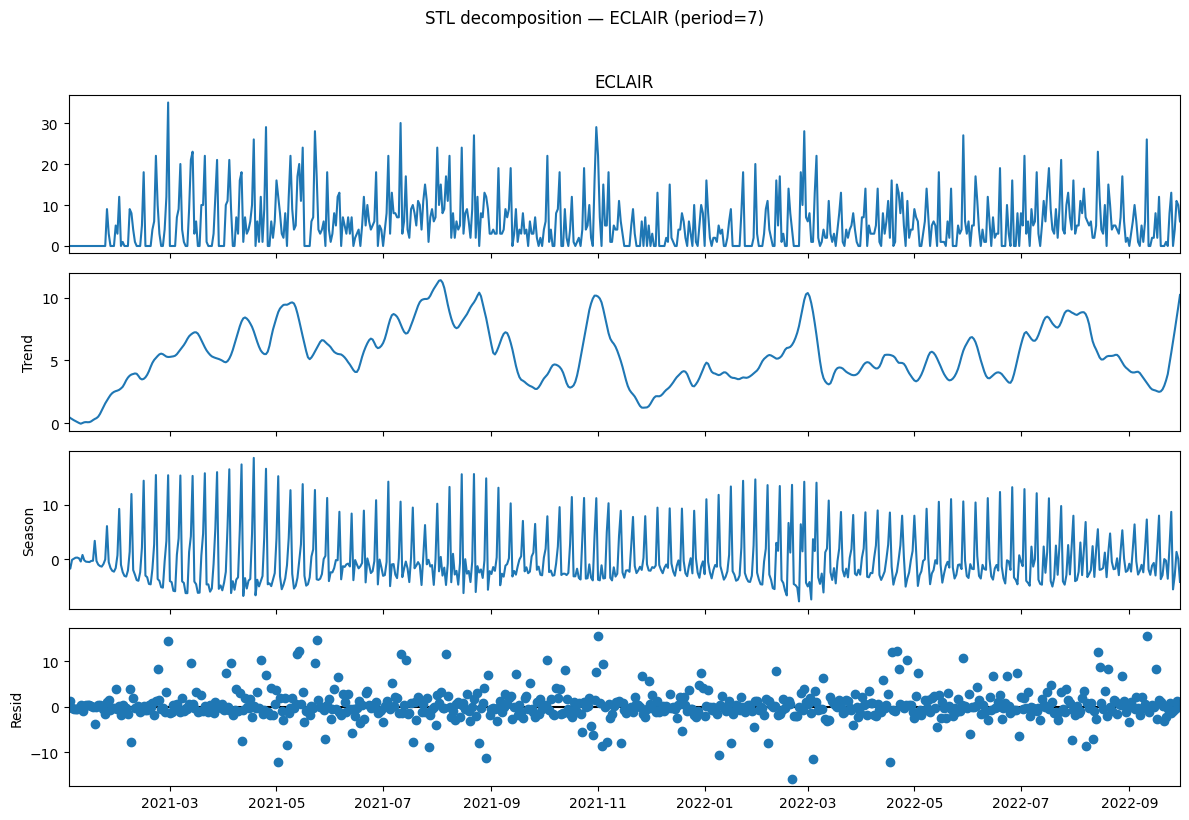

In [14]:
# STL on one representative product series

def stl_decompose(series, name, period=7, filename_prefix=None):
    s = series.asfreq("D").fillna(0)

    stl = STL(s, period=period, robust=True)
    res = stl.fit()

    fig = res.plot()
    fig.set_size_inches(12, 8)
    fig.suptitle(f"STL decomposition — {name} (period={period})", y=1.02)

    plt.tight_layout()
    if filename_prefix:
        save_show(fig, f"{filename_prefix}_stl.png")
    else:
        plt.show()

    return res

for p in top_products:
    stl_res = stl_decompose(qty_ts[p], name=f"{p}", period=7, filename_prefix=f"{p}")

# Conclusion

## Banette

### What we observe:
- The **BANETTE** daily demand shows a clear **weekly seasonality**: Sunday is the highest day, Saturday is second, and weekdays are lower and relatively close to each other (weekday bar plot + STL seasonal component).
- The series presents **strong level changes over time**: demand increases notably around mid-2021, decreases after late summer 2021, then rises again around mid-2022 before dropping toward the end (rolling means + STL trend).
- **Volatility is not constant**: the 30-day rolling standard deviation is higher during high-demand phases, and the STL residuals show **occasional large deviations** (outlier-like days).
- The **ACF stays positive for many lags and decays slowly**, with visible structure at weekly multiples, while the **PACF has a strong lag-1** effect and only a few additional small significant lags.

### What we can deduce:
- Demand is strongly driven by a **7-day repeating pattern** (weekday/weekend behavior).
- The slow ACF decay and the trend component indicate **non-stationarity** (changing mean level), so modeling the raw series with a stationary ARMA is likely insufficient.
- The process is **time-varying** (mean and variance shifts), and there are some days behaving unusually compared to the local baseline (outliers/residual spikes).

### What it implies for the project:
- The **seasonal naïve baseline** \(\hat{y}_t = y_{t-7}\) should be included and will likely be a strong benchmark due to weekly seasonality.
- A statistical model should explicitly handle **weekly seasonality (m=7)** and likely use **(seasonal) differencing** (e.g., SARIMA with \(m=7\), potentially \(d>0\) and/or \(D>0\)).
- Because demand levels and volatility change over time, keep an **outlier monitoring/interpretation step** (flag unusual dates) and consider **adaptive/online approaches** (e.g., forgetting factors) to better track regime changes.

## Baguette

### What we observe:
- The daily **BAGUETTE** demand shows a clear **weekly seasonality**: Sunday is the highest day, Saturday is second, and weekdays are lower and fairly close to each other.
- The series exhibits **medium/long-term level changes**: demand rises strongly around mid-2021, decreases after late summer 2021, then increases again around mid-2022 before dropping again toward the end of the period (visible in rolling means and STL trend).
- **Volatility is time-varying**: the 30-day rolling standard deviation increases during high-demand phases, and STL residuals contain **occasional outliers** (unusually high/low days).
- The **ACF remains positive across many lags** with noticeable structure around weekly multiples, while the **PACF has a strong lag-1** effect and only a few additional small significant lags.

### What we can deduce:
- A **7-day repeating pattern** is a dominant driver of demand (consistent with customer behavior over weekdays vs weekends).
- The slow ACF decay + trend from STL indicate **non-stationarity** (the mean level changes over time), so a stationary ARMA model on the raw series would likely be insufficient.
- The demand process is **not constant over time** (both mean and variance shift), and some specific days behave abnormally compared to their local neighborhood (outliers).

### What it implies for the project:
- Include the **seasonal naïve baseline** \(\hat{y}_t = y_{t-7}\), which should be a strong benchmark given the weekly pattern.
- For statistical modeling, prefer approaches that handle **weekly seasonality (m=7)** and likely require **(seasonal) differencing** (e.g., SARIMA with \(m=7\), possibly with \(d>0\) and/or \(D>0\)).
- Because the series has regime changes and occasional extreme days, it is useful to keep an **outlier monitoring step** (flag and interpret unusual dates) and consider **adaptive/online methods** (e.g., forgetting factors) to better track evolving demand levels.

## Boule 400G

### What we observe:
- **BOULE 400G** has a clear **weekly seasonality**: demand is higher on weekends (especially Sunday), and lower during weekdays (weekday bar plot + STL seasonal component).
- The overall level is **lower and noisier** than the baguette products (most days are in the single digits / low tens), with **occasional sharp spikes** (visible in the daily plot and in the STL residuals).
- Rolling means (7d/30d) and the STL trend suggest **slow level changes** over time (milder “regime” shifts than for baguettes, but still present).
- The 30-day rolling std shows **time-varying volatility**, with certain periods having noticeably higher variability.
- The **ACF decays faster** than for the baguette series, but still shows **positive correlations** and a weekly structure; the **PACF is dominated by lag 1** with only a few small additional significant lags.

### What we can deduce:
- Weekly seasonality is still an important driver (weekend effect), but the series is **more intermittent** (many low-demand days and occasional spikes).
- The dependence structure looks **short-memory** (strong lag-1 effect, faster ACF decay), and non-stationarity is present but **less pronounced** than for the highest-volume products.
- Spikes/outliers likely correspond to **special events, bulk purchases, or irregular demand**, which can strongly affect error metrics if not monitored.

### What it implies for the project:
- The **seasonal naïve baseline** \(\hat{y}_t = y_{t-7}\) remains relevant (weekly pattern), but because demand is lower and spikier, you should also compare with a simple **moving average** baseline.
- A **SARIMA with weekly seasonality (m=7)** is still reasonable, but you may need a **simpler structure** (small p/q) and careful handling of low counts/spikes; in practice, the model choice may be more sensitive to outliers than for high-volume products.
- Keep an explicit **outlier monitoring step** (list unusual dates) and consider **robust/adaptive approaches** (e.g., forgetting factor) so the model does not overfit old spikes and can adapt to changing demand levels.

## Campagne

### What we observe:
- **CAMPAGNE** shows a visible **weekly seasonality**: weekends are higher (Sunday highest, Saturday second), while weekdays are lower and relatively close (weekday bar plot + STL seasonal component).
- The daily series is **low-to-moderate demand with spikes**: many days are in the low range, but there are occasional sharp peaks (daily plot + STL residuals).
- Rolling means and the STL trend indicate **medium/long-term level changes**: demand rises during mid-2021, drops after late summer 2021, then gradually increases again in 2022 with a noticeable bump around summer before decreasing (rolling means + STL trend).
- The 30-day rolling std suggests **time-varying volatility**, with higher variability during higher-demand phases.
- The **ACF stays positive across many lags** and decays slowly, while the **PACF is dominated by lag 1** with only a few smaller significant lags.

### What we can deduce:
- Weekly seasonality is an important driver, consistent with **weekday/weekend customer behavior**.
- The slow ACF decay and visible trend suggest **non-stationarity** (changing mean level), so modeling the raw series with a stationary ARMA is likely insufficient.
- The presence of spikes/outliers indicates **irregular demand events** (bulk purchases, special days, or data issues), which can affect model fit and evaluation.

### What it implies for the project:
- Include a strong benchmark such as the **seasonal naïve baseline** \(\hat{y}_t = y_{t-7}\), and also compare with a **moving average** baseline because the series is relatively noisy.
- A **SARIMA model with weekly seasonality (m=7)** is a reasonable candidate, likely with **(seasonal) differencing** if needed to handle non-stationarity.
- Keep an **outlier monitoring step** (flag unusual dates for interpretation) and consider **adaptive/online approaches** (forgetting factors) so the model can track changing demand levels without being overly influenced by old spikes.

## Cereal Baguette

### What we observe:
- **CEREAL BAGUETTE** shows a clear **weekly seasonality**: weekends are higher (Sunday highest, Saturday second), while weekdays are lower and relatively close (weekday bar plot + STL seasonal component).
- The daily series has **moderate demand with many spikes and some low/zero-like days**, making it more irregular than a smooth “high-volume” product (daily plot + residuals).
- Rolling means and the STL trend indicate **pronounced medium/long-term level changes**: demand increases through the first half of 2021, peaks around mid-2021 / summer, decreases afterward, then rises again in mid-2022 before falling toward the end (rolling means + STL trend).
- The 30-day rolling std shows **strongly time-varying volatility**, with higher variability during high-demand phases.
- The **ACF remains positive for many lags** and decays slowly (suggesting persistence + trend/seasonality), while the **PACF is dominated by lag 1** with a few smaller significant lags.

### What we can deduce:
- A **7-day repeating pattern** is a major component of demand (weekday/weekend behavior).
- The slow ACF decay + STL trend implies **non-stationarity** (changing mean level), so a stationary ARMA on the raw series is unlikely to fit well.
- The series is **noisy and spiky**: some “event days” or irregular purchases create outliers that can distort parameter estimation and evaluation if not monitored.

### What it implies for the project:
- Use the **seasonal naïve baseline** \(\hat{y}_t = y_{t-7}\) as a key benchmark, and also compare with a **moving average** baseline because variability is high.
- A **SARIMA model with weekly seasonality (m=7)** is a natural candidate, likely requiring **(seasonal) differencing** (e.g., \(d>0\) and/or \(D>0\)) to address non-stationarity.
- Keep an **outlier monitoring step** (flag and interpret unusual dates) and consider **adaptive/online approaches** (forgetting factors) so the model can track evolving demand levels and reduce sensitivity to older spikes.

## Cookie

### What we observe:
- **COOKIE** shows a **weaker weekly seasonality** than bread products: there is still a small weekend uplift (Fri/Sat/Sun slightly higher), but the weekday differences are modest (weekday bar plot + STL seasonal component with smaller amplitude).
- The series is **low-to-moderate demand with frequent fluctuations** and several **short bursts/spikes** (notably around late summer 2021 and again in summer 2022), visible in the raw series and rolling means.
- Rolling means and the STL trend reveal **non-constant level**: a gradual increase into mid/late 2021, a drop afterward, then a marked rise in mid-2022 followed by a decline near the end.
- The 30-day rolling std indicates **time-varying volatility**, with a clear volatility increase during the high-demand burst in mid-2022.
- The **ACF is positive but decays faster** than for baguettes, and the **PACF shows a strong lag-1** effect plus a few small early-lag contributions.

### What we can deduce:
- Demand still has a **weekly pattern**, but it is **less dominant**; cookies behave more like an **irregular / promotion-sensitive** product compared to staple breads.
- The trend component suggests **non-stationarity** (changing baseline demand), but the dependence structure looks more **short-memory** (lag-1 dominates).
- Spikes and volatility jumps suggest **event-driven demand** (e.g., promotions, special days, or stock effects), which can distort model fitting if not monitored.

### What it implies for the project:
- Keep the **seasonal naïve baseline** \(\hat{y}_t = y_{t-7}\), but do not expect it to dominate as much as for baguettes; also compare with a **moving average** baseline.
- A **SARIMA with weekly seasonality (m=7)** may still work, but likely with a **simpler non-seasonal structure** and careful tuning; in practice, capturing the **trend/level shifts** may matter more than complex seasonality.
- Because spikes and volatility regimes are important, keep an **outlier monitoring step** (flag unusual dates) and consider **adaptive/online approaches** (forgetting factors) to track recent changes without being overly influenced by older bursts.

## Croissant

### What we observe:
- **CROISSANT** has a **very strong weekly seasonality**: demand is much higher on weekends, with **Sunday far above all other days** and Saturday clearly second (weekday bar plot + STL seasonal component with large amplitude).
- The series shows **large spikes and high variability**, especially during high-demand phases (raw series + many large residual points).
- Rolling means and the STL trend indicate **clear regime changes / long swings**: an increase into mid-2021, a drop after late summer 2021, then a strong rise again in mid-2022 followed by a decline toward the end (rolling means + STL trend).
- Volatility is **strongly time-varying** (rolling std increases substantially during high-demand periods, especially in 2022).
- The **ACF shows strong periodic structure** at weekly multiples (notably around lag 7, 14, 21, 28), while the **PACF is dominated by lag 1** with some additional seasonal-related spikes.

### What we can deduce:
- The demand is driven primarily by a **7-day repeating pattern** (weekend behavior dominates), making CROISSANT highly seasonal.
- The series is **non-stationary** (changing mean level over time) and also **heteroskedastic** (variance changes with the level), so a simple stationary ARMA on the raw data would be inadequate.
- Outliers/spikes suggest **event-driven days** (e.g., exceptional weekends, special events, stock effects), which can heavily influence model estimation and error metrics.

### What it implies for the project:
- The **seasonal naïve baseline** \(\hat{y}_t = y_{t-7}\) should be an essential benchmark and is likely to perform strongly given the dominant weekly pattern.
- A **SARIMA model with weekly seasonality (m=7)** is a natural choice, likely requiring **(seasonal) differencing** to handle non-stationarity; alternatively, **STL + model on residuals** is a good structured approach.
- Because volatility and spikes are large, keep an explicit **outlier monitoring/interpretation step**, and consider **adaptive/online methods** (forgetting factors) to better track regime changes and reduce sensitivity to older high-variance periods.

## Eclair

### What we observe:
- **ECLAIR** is **highly intermittent**: many days are near zero, with frequent sharp spikes (raw series), and the rolling means stay relatively low compared to the size of some peaks.
- The **weekday seasonality is very strong and asymmetric**: **Sunday dominates** by a large margin, Saturday is higher than weekdays, and weekdays are much lower (weekday bar plot). The STL seasonal component also shows a strong weekly pattern.
- Rolling means and the STL trend show **level shifts over time**: an initial ramp-up early 2021 (from almost no sales to a positive baseline), a higher period in spring/summer 2021, a lower plateau later in 2021, then a gradual rise again in 2022 with some bursts (rolling means + STL trend).
- The **ACF is not slowly decaying like a classic trending series**; instead it shows **clear seasonal spikes at weekly multiples** (around 7, 14, 21, 28, 35) and relatively weak correlations elsewhere. The **PACF** is mostly small except for a few seasonal-related lags.
- Volatility (rolling std) increases sharply after the start (consistent with the series “turning on” from near-zero) and then remains **moderate but variable**, reflecting the spiky nature of demand.

### What we can deduce:
- Demand is dominated by **calendar effects** (especially Sundays) and behaves like a **low-count / intermittent** time series rather than a smooth high-volume product.
- The strong peaks at weekly multiples in ACF/PACF confirm a **7-day seasonal structure**, while the lack of strong persistence at other lags suggests **limited short-memory** once seasonality is accounted for.
- Spikes/outliers are a core feature (not rare noise), likely driven by **events, weekend traffic, or batch purchases**, so treating them explicitly matters.

### What it implies for the project:
- The **seasonal naïve baseline** \(\hat{y}_t = y_{t-7}\) is essential here and should perform well because the weekly calendar effect is dominant (especially for Sundays).
- A **SARIMA with weekly seasonality (m=7)** can work, but because the series is intermittent and spiky, you should keep the model **simple** and consider strategies that are robust to zeros/spikes (e.g., STL + residual model, or adaptive/online smoothing).
- Keep an explicit **outlier monitoring step** and consider forecasting at different granularities (e.g., separate “Sunday vs non-Sunday” behavior, or using day-of-week features) to better capture the extreme Sunday-driven demand.

## Pain au chocolat

### What we observe:
- **PAIN AU CHOCOLAT** shows a **very strong weekly seasonality**: demand increases sharply on weekends, with **Sunday clearly the highest** and Saturday second (weekday bar plot + STL seasonal component with large amplitude).
- The series has **high variability and frequent spikes**, especially during high-demand phases (raw series + many large residual points in STL).
- Rolling means and the STL trend reveal **clear regime changes**: a strong rise into mid/late summer 2021, a drop afterward, then another strong rise in mid-2022 followed by a decline near the end (rolling means + STL trend).
- Volatility is **time-varying** (rolling std increases substantially during high-demand periods, especially around summer peaks).
- The **ACF shows strong periodic structure** at weekly multiples (around lag 7, 14, 21, 28, 35), and the **PACF is dominated by lag 1** with additional seasonal-related spikes.

### What we can deduce:
- Demand is largely driven by a **7-day repeating pattern** (weekend effect dominates), making this product strongly seasonal.
- The presence of a pronounced trend component implies **non-stationarity**, and the changing volatility indicates **heteroskedasticity** (variance grows during high-demand periods).
- Outliers/spikes are important and likely correspond to **events, special weekends, or exceptional purchasing behavior**, which can distort model fitting if ignored.

### What it implies for the project:
- The **seasonal naïve baseline** \(\hat{y}_t = y_{t-7}\) is an essential benchmark and should perform well given the dominant weekly structure.
- A **SARIMA model with weekly seasonality (m=7)** is a natural candidate, likely requiring **(seasonal) differencing** to handle non-stationarity; alternatively, **STL + model on residuals** is a strong structured approach.
- Because spikes and volatility regimes are large, keep an explicit **outlier monitoring/interpretation step**, and consider **adaptive/online methods** (forgetting factors) to better track changing demand levels and reduce sensitivity to older high-variance periods.

## Special Bread

### What we observe:
- **SPECIAL BREAD** shows a clear **weekly seasonality**: weekends are higher with **Sunday highest** and Saturday second, while weekdays are lower and fairly close (weekday bar plot + STL seasonal component).
- The series is **moderate demand** (single digits to ~20+) with some spikes, but overall looks **less extreme** than high-volume items like croissant/pain au chocolat (raw series + residuals).
- Rolling means and the STL trend indicate **level changes over time**: a noticeable rise into mid-2021 with a peak around summer, a decline afterward, then another increase during mid-2022 before decreasing toward the end (rolling means + STL trend).
- The 30-day rolling std shows **time-varying volatility**, but at a **lower scale** than very high-demand products (volatility increases during higher-demand phases).
- The **ACF remains positive and decays slowly** with some weekly structure, while the **PACF is dominated by lag 1** and only a few small additional significant lags.

### What we can deduce:
- A **7-day repeating pattern** is a key driver (weekend uplift), but the series is generally **more stable** than products with very large weekend surges.
- The slow ACF decay and trend component imply **non-stationarity** (changing mean level), though regime shifts appear **milder** than for the top-selling products.
- Occasional spikes suggest event-driven days, but they are not as dominant; the series still has a meaningful predictable component.

### What it implies for the project:
- The **seasonal naïve baseline** \(\hat{y}_t = y_{t-7}\) should be included and should work well due to weekly seasonality.
- A **SARIMA with weekly seasonality (m=7)** is a reasonable candidate; it may require **(seasonal) differencing** depending on stationarity after removing seasonality/trend.
- Keep a light **outlier monitoring step** (flag unusual dates), and consider **adaptive/online smoothing** if you want the model to react quickly to gradual level changes without overfitting older periods.

## Tartelette

### What we observe:
- **TARTELETTE** is **intermittent and spiky**: many low-demand days mixed with occasional large peaks (raw series), and rolling means stay moderate compared to the size of spikes.
- The **weekly seasonality is strong and highly asymmetric**: **Sunday dominates** clearly, Saturday is higher than weekdays, and weekdays are much lower (weekday bar plot + STL seasonal component with strong weekly pattern).
- Rolling means and the STL trend show **level shifts over time**: a ramp-up early 2021 (from near-zero to a stable baseline), a higher period around mid-2021, a lower period around late 2021 / early 2022, then an increase again in mid-2022 before declining toward the end (rolling means + STL trend).
- The **ACF is not strongly persistent** at all lags; instead, it shows **distinct seasonal spikes at weekly multiples** (around 7, 14, 21, 28, 35), while most other lags are near zero. The **PACF** similarly shows mostly small values except for seasonal-related lags.
- Rolling volatility (std 30d) is **time-varying**, with higher variability during periods where peaks are more frequent.

### What we can deduce:
- Demand is largely driven by **calendar effects**, especially Sundays, and behaves like a **low-count / intermittent** series rather than a smooth high-volume product.
- The correlation structure suggests **weekly seasonality dominates** more than short-term autoregressive memory (outside seasonal lags, correlations are weak).
- Spikes/outliers are intrinsic to this product (likely event-driven purchases), so they must be monitored when fitting and evaluating models.

### What it implies for the project:
- The **seasonal naïve baseline** \(\hat{y}_t = y_{t-7}\) is crucial and should be a strong benchmark given the dominant weekly pattern.
- A **SARIMA with weekly seasonality (m=7)** can be tested, but because the series is intermittent/spiky, consider robust alternatives such as **STL + residual model**, or an approach using **day-of-week features**.
- Keep an explicit **outlier monitoring step** (flag unusual dates) and consider **adaptive/online smoothing** (forgetting factors) to track level changes without being overly influenced by older spikes.

## Traditionnal baguette

### What we observe:
- The daily demand is clearly **weekly seasonal**: weekends (especially Sunday) are much higher than weekdays.
- The level of the series is **not stable over time**: there are strong **regime changes / long swings** (e.g., large increases during summer periods followed by sharp decreases).
- **Volatility changes over time** (rolling std is much higher during high-activity periods), and STL residuals show **occasional large outliers**.
- The **ACF stays positive for many lags and decays slowly**, while the **PACF shows a strong lag-1 effect**, consistent with dependence on recent days plus weekly structure.

### What we can deduce:
- Weekly seasonality is a dominant driver, so the process likely has a strong **7-day repeating pattern**.
- The slow ACF decay + visible trend components indicate **non-stationarity** (trend and/or seasonal effects not removed).
- Demand dynamics are **time-varying** (both mean level and variance change), and some days are **atypical** relative to the local baseline.

### What it implies for the project:
- A strong baseline is the **seasonal naïve** forecast hat(y)_t = y_(t-7); it should be included for comparison.
- Modeling should consider **seasonal structure (m=7)** and likely **differencing** (ARIMA/SARIMA with seasonal differencing if needed).
- Because of regime changes and varying volatility, it is worth testing **adaptive/online approaches** (e.g., forgetting factors) and keeping an **outlier monitoring step** (flag unusual days and interpret them rather than blindly fitting to them).

# Conclusion of conclusion

Across the 12 bakery products, the dominant pattern is a **strong weekly seasonality**: demand systematically increases on weekends, with **Sunday almost always the peak day** and Saturday typically second. This weekly structure is visible in weekday averages and confirmed by **ACF/PACF peaks at lags 7, 14, 21, …**, meaning a large part of the signal is calendar-driven. In addition, most series show **non-stationarity** with **level changes over time** (trend/regime shifts), often with higher demand phases (e.g., mid-year/summer peaks) followed by lower phases, which implies that the “average demand” is not constant through the full period. Volatility is also **time-varying**: high-demand phases tend to come with higher variability, and several products (especially pastries/desserts and some breads) exhibit **spikes/outliers** that likely correspond to special events, unusual weekends, bulk purchases, or operational effects.

**Implications for the forecasting project:**  
- Use the **seasonal naïve baseline** hat{y}_t = y_{t-7} as a key benchmark for every product (it should be strong given the weekly seasonality).  
- Favor models that explicitly handle **weekly seasonality (m=7)** and **level changes** (e.g., SARIMA with seasonal components and possible differencing, or STL decomposition + a model on residuals).  
- Keep an **outlier monitoring step** (flag and interpret abnormal dates) because spikes can strongly impact training and evaluation.  
- Because demand regimes evolve, consider **adaptive/online mechanisms** (e.g., rolling training windows, forgetting factors) to react to recent patterns rather than fitting one static model over the whole history.